# AI Bubble Detection — Summary Graphs

Visualisations structured around the five research questions and seven hypotheses.

| Figure | RQ / Hypothesis |
|--------|----------------|
| 1 | **SQ1 / H3** — Index vs individual securities (dilution test) |
| 2 | **H1** — Post-ChatGPT explosiveness: BSADF paths + both SV-ADF windows per ticker |
| 3 | **SQ2 / H2** — Value-chain heatmap with GSADF and both SV-ADF episode overlays |
| 4 | **SQ2 / H2** — Segment episode-rate comparison across all three methods |
| 5 | **SQ3 / H4** — Method agreement: SADF × GSADF × SV-ADF W1 × SV-ADF W2 |
| 6 | **SQ4 / H6** — Commodity propagation with both SV-ADF windows |
| 7 | **SQ5 / H5** — Historical validation: dot-com and pre-GFC |
| 8 | **H7** — Structural event overlay with all episode originations |

**SV-ADF windows**:
- **W1** (post-ChatGPT): `SVADF_DEFAULT_START → SVADF_DEFAULT_END` (orange)
- **W2** (pre-ChatGPT): `SVADF_PRE_GPT_START → SVADF_PRE_GPT_END` (teal)

> Prerequisite: run `scripts/03_run_analysis.py --methods all` so both SV-ADF windows are cached.

## 0 · Setup

Imports, project-root resolution, price cache, and master results table.
Defines colour constants and SV-ADF window labels used by every figure below.

In [68]:
import sys, warnings
from pathlib import Path

for candidate in [Path.cwd().parent, Path.cwd()]:
    if (candidate / "config" / "settings.py").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates  as mdates
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

from config import settings
from src.io.results import (
    load_stationarity, load_sadf, load_gsadf, load_svadf,
    list_svadf_windows, available_tickers,
)
from src.io.data import load_or_download_prices

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 10,
})

# ── SV-ADF window definitions ──────────────────────────────────────────────────
SVADF_WIN1   = (settings.SVADF_DEFAULT_START, settings.SVADF_DEFAULT_END)
SVADF_WIN2   = (settings.SVADF_PRE_GPT_START, settings.SVADF_PRE_GPT_END)
WIN1_LABEL   = f"SV-ADF W1 post-ChatGPT ({SVADF_WIN1[0]}→{SVADF_WIN1[1]})"
WIN2_LABEL   = f"SV-ADF W2 pre-ChatGPT  ({SVADF_WIN2[0]}→{SVADF_WIN2[1]})"
W1_COLOR     = "#e76f51"   # orange
W2_COLOR     = "#2a9d8f"   # teal
GSADF_COLOR  = "#e63946"   # red
CHATGPT      = pd.Timestamp("2022-11-30")
FIGDIR       = settings.FIGURES_DIR / "thesis"
FIGDIR.mkdir(parents=True, exist_ok=True)

print(f"W1: {WIN1_LABEL}")
print(f"W2: {WIN2_LABEL}")
print(f"Available tickers with results: {available_tickers()}")

W1: SV-ADF W1 post-ChatGPT (2021-11-01â†’2026-05-01)
W2: SV-ADF W2 pre-ChatGPT  (2020-01-01â†’2022-10-31)
Available tickers with results: ['AAPL', 'AI', 'AMAT', 'AMD', 'AMZN', 'ANET', 'ASML', 'ASX', 'AVGO', 'BNO', 'CEG', 'CIEN', 'CORN', 'COW', 'CRWV', 'CSCO', 'DBA', 'DBC', 'DDOG', 'DLR', 'EQIX', 'GLD', 'GOOGL', 'GSG', 'IBM', 'INTC', 'JJC', 'LRCX', 'META', 'MRVL', 'MSFT', 'MU', 'NASDAQ', 'NBIS', 'NOK', 'NVDA', 'ORCL', 'PALL', 'PDBC', 'PLTR', 'PPLT', 'QCOM', 'SLV', 'SNOW', 'SOYB', 'SP500', 'STX', 'TSLA', 'TSM', 'UNG', 'USO', 'VST', 'WDC', 'WEAT', '^GSPC', '^IXIC', '^SOX']


In [69]:
# ── Load prices ────────────────────────────────────────────────────────────────
try:
    prices = load_or_download_prices(force=False)
    print(f"Prices: {prices.shape}")
except Exception as e:
    prices = pd.DataFrame()
    print(f"Warning: prices unavailable ({e})")

# ── Helper loaders ─────────────────────────────────────────────────────────────
def _gsadf(tk):      r = load_gsadf(tk);          return r["summary"] if r else None
def _sadf(tk):       return load_sadf(tk)
def _sv(tk, win):    r = load_svadf(tk, *win);    return r["summary"] if r else None
def _sv_paths(tk, win): r = load_svadf(tk, *win); return r["paths"]   if r else None

# ── Build master results table ─────────────────────────────────────────────────
rows = []
for tk in settings.ALL_TICKERS:
    seg, desc = settings.SEGMENT_OF.get(tk, ("?", ""))
    gs   = _gsadf(tk)
    sa   = _sadf(tk)
    sv1  = _sv(tk, SVADF_WIN1)
    sv2  = _sv(tk, SVADF_WIN2)
    row  = {
        "ticker"        : tk,
        "segment"       : seg,
        "desc"          : desc,
        "is_equity"     : not seg.startswith("C.") and not seg.startswith("0."),
        "is_index"      : seg.startswith("0."),
        "is_commodity"  : seg.startswith("C."),
        "sadf_stat"     : sa["statistic"]   if sa else np.nan,
        "sadf_signal"   : sa["signal"]      if sa else False,
        "gsadf_stat"    : gs["statistic"]   if gs else np.nan,
        "gsadf_cv"      : gs["cv_value"]    if gs else np.nan,
        "gsadf_reject"  : gs["reject"]      if gs else False,
        "gsadf_n_ep"    : len(gs["episodes"]) if gs else 0,
        "gsadf_episodes": gs["episodes"]    if gs else [],
        "sv_w1_has_ep"  : (sv1["episode"] is not None) if sv1 else False,
        "sv_w1_episode" : sv1["episode"]    if sv1 else None,
        "sv_w2_has_ep"  : (sv2["episode"] is not None) if sv2 else False,
        "sv_w2_episode" : sv2["episode"]    if sv2 else None,
    }
    rows.append(row)

master = pd.DataFrame(rows)
print(f"Master: {len(master)} tickers, "
      f"{master['gsadf_stat'].notna().sum()} with GSADF, "
      f"{master['sv_w1_has_ep'].sum()} SV W1 episodes, "
      f"{master['sv_w2_has_ep'].sum()} SV W2 episodes")

Loading cached prices from C:\Users\Carer\Downloads\ai-bubble-detection-final\ai-bubble-detection\data\prices\prices.csv
Prices: (1590, 58)
Master: 55 tickers, 55 with GSADF, 22 SV W1 episodes, 15 SV W2 episodes


---
## Figure 1 — SQ1 / H3: Index dilution test

Two-panel comparison of GSADF statistics across individual equities vs broad index benchmarks.
Tests H3: explosive behaviour is detectable in individual securities but masked when aggregated
into an index. Left panel: ranked GSADF stats with index values overlaid as dotted lines.
Right panel: per-ticker binary verdict grid (green = GSADF rejects H₀ / episode detected).

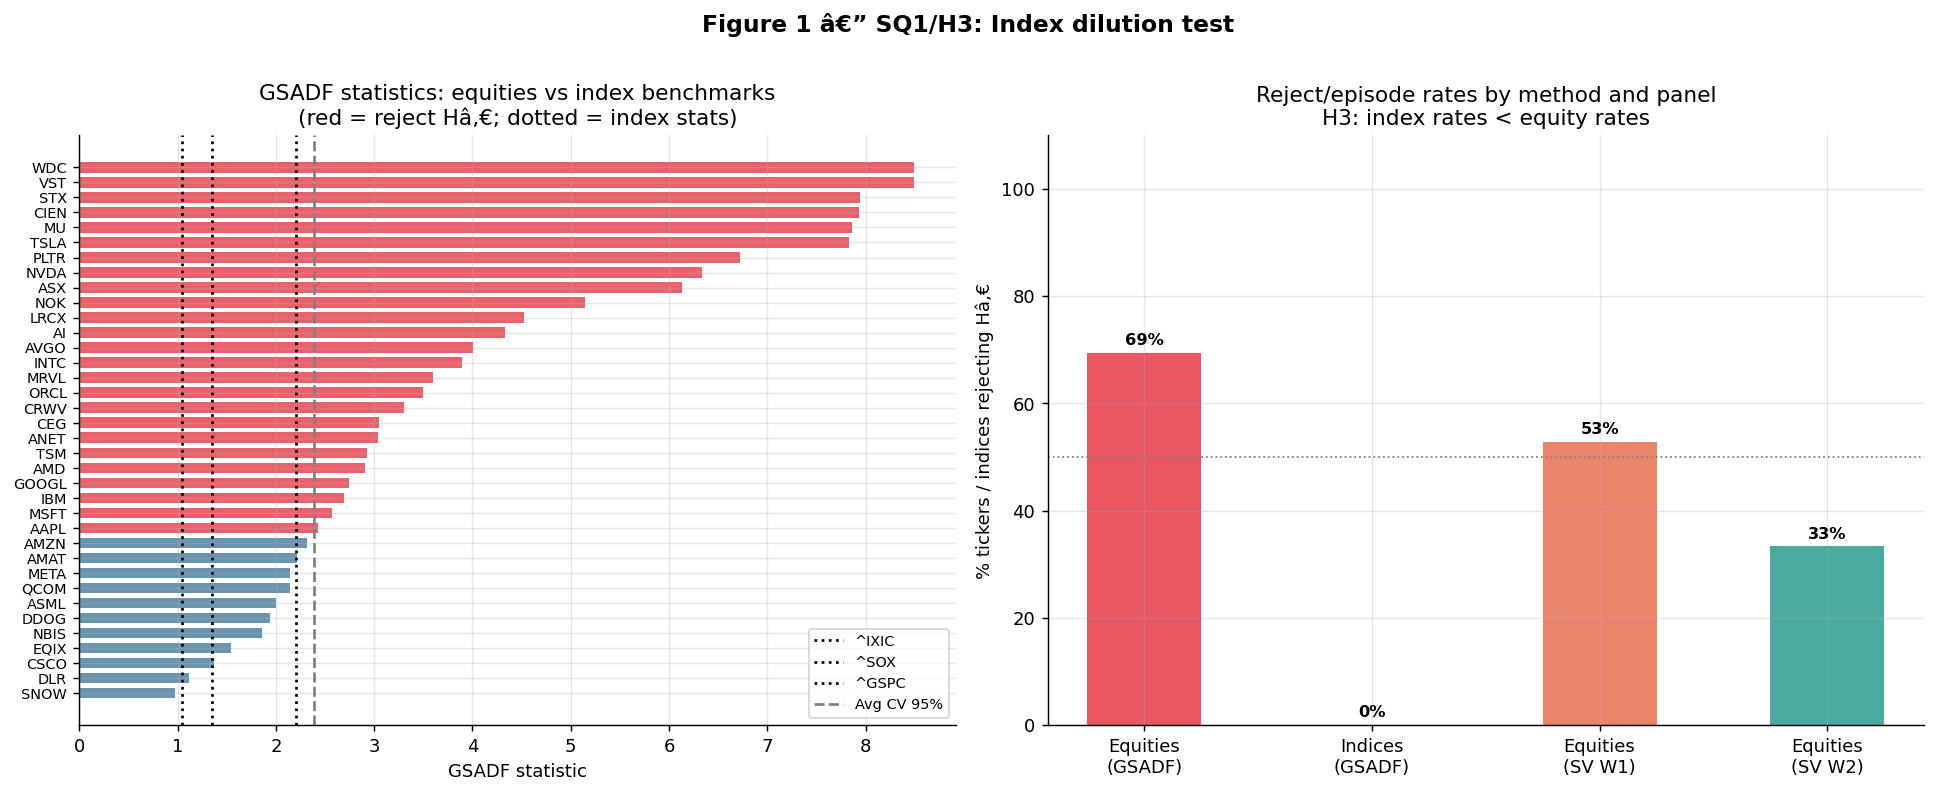

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

eq  = master[master["is_equity"] & master["gsadf_stat"].notna()].sort_values("gsadf_stat")
idx = master[master["is_index"]  & master["gsadf_stat"].notna()]

# ── Left: GSADF statistics, equities with index dotted lines ──────────────────
ax = axes[0]
colors = [GSADF_COLOR if r else "#457b9d" for r in eq["gsadf_reject"]]
ax.barh(range(len(eq)), eq["gsadf_stat"], color=colors, alpha=0.8, height=0.7)
for _, row in idx.iterrows():
    ax.axvline(row["gsadf_stat"], color="black", ls=":", lw=1.5, label=row["ticker"])
if not idx.empty:
    ax.axvline(idx["gsadf_cv"].mean(), color="grey", ls="--", lw=1.5, label="Avg CV 95%")
ax.set_yticks(range(len(eq)))
ax.set_yticklabels(eq["ticker"], fontsize=8)
ax.set_xlabel("GSADF statistic")
ax.set_title("GSADF statistics: equities vs index benchmarks\n(red = reject H₀; dotted = index stats)")
ax.legend(fontsize=8, loc="lower right")

# ── Right: reject rate breakdown ─────────────────────────────────────────────
ax2 = axes[1]
groups = {
    "Equities\n(GSADF)"  : master[master["is_equity"] & master["gsadf_stat"].notna()]["gsadf_reject"].mean(),
    "Indices\n(GSADF)"   : master[master["is_index"]  & master["gsadf_stat"].notna()]["gsadf_reject"].mean() if (master["is_index"] & master["gsadf_stat"].notna()).any() else 0,
    "Equities\n(SV W1)"  : master[master["is_equity"] & master["gsadf_stat"].notna()]["sv_w1_has_ep"].mean(),
    "Equities\n(SV W2)"  : master[master["is_equity"] & master["gsadf_stat"].notna()]["sv_w2_has_ep"].mean(),
}
bar_colors = [GSADF_COLOR, "#264653", W1_COLOR, W2_COLOR]
bars = ax2.bar(list(groups.keys()), [v*100 for v in groups.values()],
               color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, groups.values()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f"{val*100:.0f}%", ha="center", fontweight="bold", fontsize=9)
ax2.set_ylim(0, 110)
ax2.set_ylabel("% tickers / indices rejecting H₀")
ax2.set_title("Reject/episode rates by method and panel\nH3: index rates < equity rates")
ax2.axhline(50, color="grey", ls=":", lw=1)

plt.suptitle("Figure 1 — SQ1/H3: Index dilution test", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "fig1_index_dilution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Figure 2 — H1: BSADF paths with both SV-ADF windows per ticker

One two-row panel per focus ticker (NVDA, AMD, AVGO, MU, TSM, PLTR, MSFT, ANET):
- **Top**: price series with episode shading — GSADF (red), SV-ADF W1 (orange), SV-ADF W2 (teal)
- **Bottom**: test statistics normalised to their own thresholds so all three are directly
  comparable on the same axis (value > 1 = above threshold / explosive)

Saves to `outputs/figures/thesis/fig2_bsadf_paths.png`.

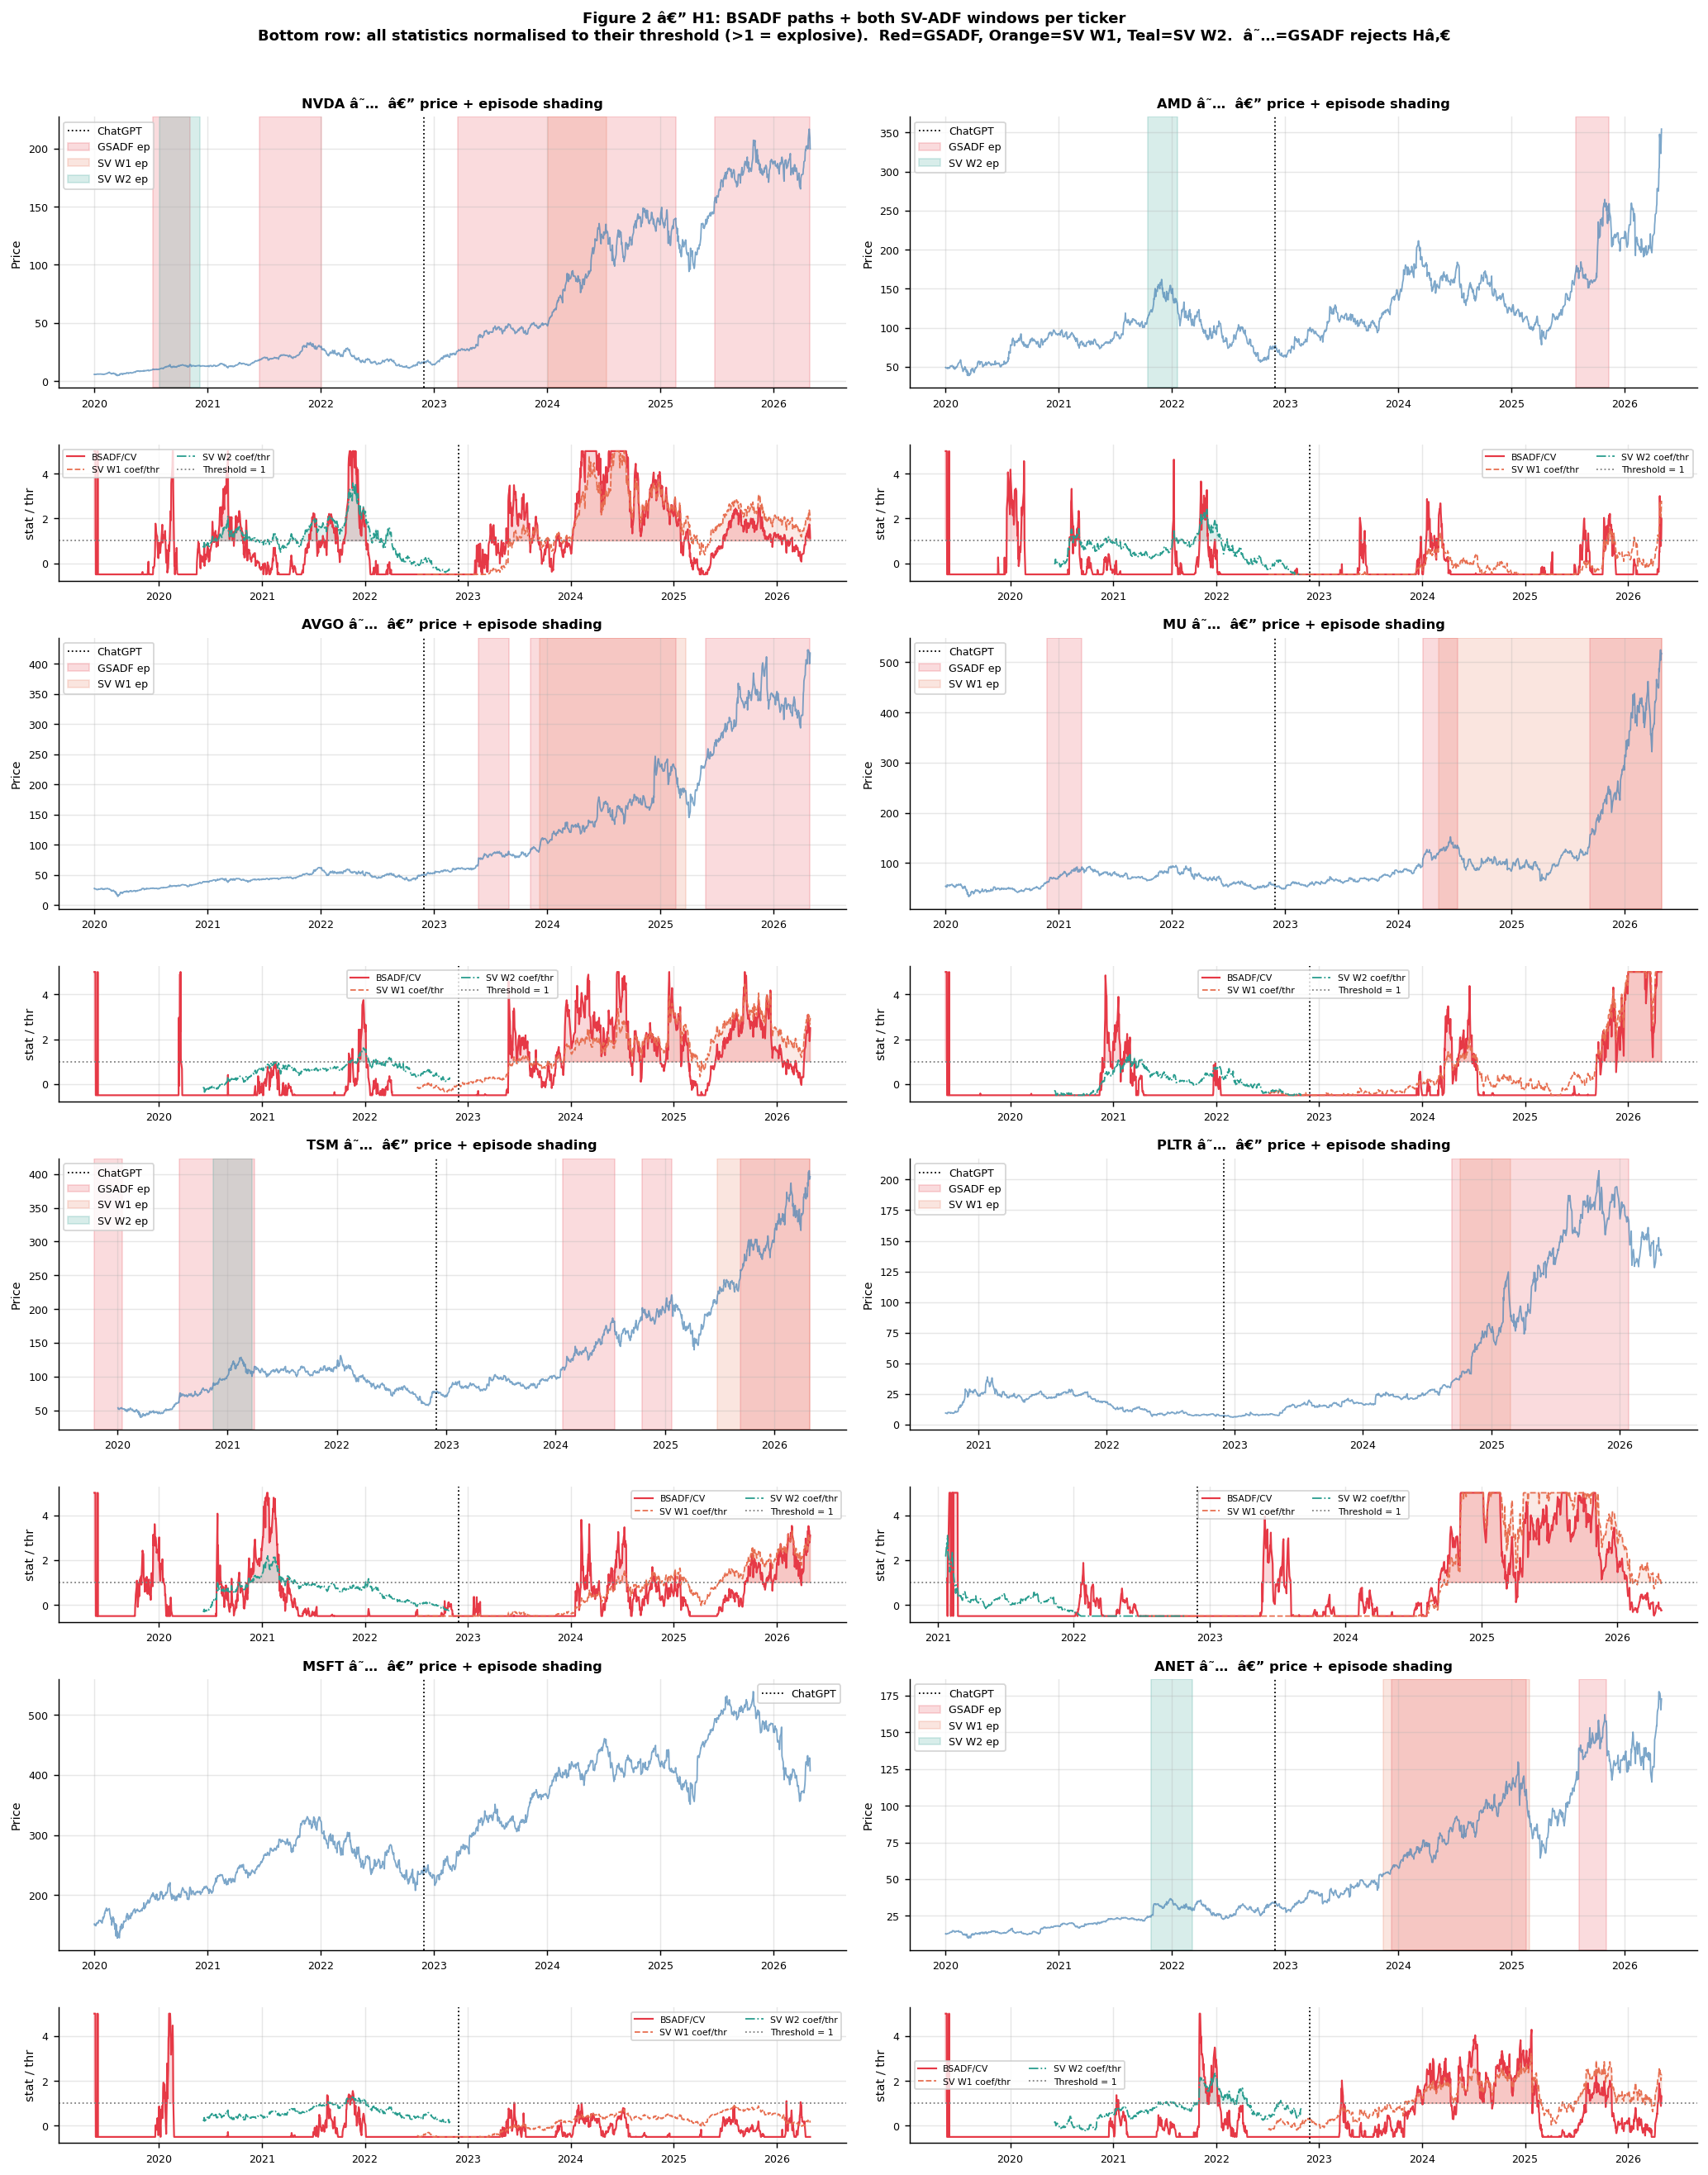

In [ ]:
FOCUS = [t for t in ["NVDA","AMD","AVGO","MU","TSM","PLTR","MSFT","ANET"]
         if load_gsadf(t) is not None]

if not prices.empty and FOCUS:
    N_COLS  = 2
    N_TROWS = int(np.ceil(len(FOCUS) / N_COLS))  # ticker rows
    # each ticker block = 2 subplot rows (price + stats)
    fig, axes = plt.subplots(N_TROWS * 2, N_COLS,
                             figsize=(16, 5 * N_TROWS),
                             gridspec_kw={"height_ratios": [2, 1] * N_TROWS})
    axes = np.array(axes).reshape(N_TROWS * 2, N_COLS)

    for i, tk in enumerate(FOCUS):
        col      = i % N_COLS
        trow     = i // N_COLS          # which ticker-row block
        ax_price = axes[trow * 2,     col]
        ax_stat  = axes[trow * 2 + 1, col]

        gs_res   = load_gsadf(tk)
        if gs_res is None:
            ax_price.set_visible(False); ax_stat.set_visible(False); continue
        paths = gs_res["paths"]
        summ  = gs_res["summary"]
        sv1p  = _sv_paths(tk, SVADF_WIN1)
        sv2p  = _sv_paths(tk, SVADF_WIN2)

        # ── Price panel ──────────────────────────────────────────────────────
        if tk in prices.columns:
            p = prices[tk].dropna()
            ax_price.plot(p.index, p.values, color="steelblue", lw=1, alpha=0.7)
        ax_price.axvline(CHATGPT, color="black", ls=":", lw=1, label="ChatGPT")

        # GSADF episode shading
        for ep in summ["episodes"]:
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.18, color=GSADF_COLOR, label="GSADF ep")
        # SV-ADF W1 episode shading
        sv1_sum = _sv(tk, SVADF_WIN1)
        if sv1_sum and sv1_sum["episode"]:
            ep = sv1_sum["episode"]
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.18, color=W1_COLOR, label="SV W1 ep")
        # SV-ADF W2 episode shading
        sv2_sum = _sv(tk, SVADF_WIN2)
        if sv2_sum and sv2_sum["episode"]:
            ep = sv2_sum["episode"]
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.18, color=W2_COLOR, label="SV W2 ep")

        handles, labels = ax_price.get_legend_handles_labels()
        ax_price.legend(dict(zip(labels, handles)).values(),
                        dict(zip(labels, handles)).keys(), fontsize=7)
        star = "★" if summ["reject"] else ""
        ax_price.set_title(f"{tk} {star}  — price + episode shading", fontsize=9, fontweight="bold")
        ax_price.set_ylabel("Price", fontsize=8)
        ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_price.tick_params(labelsize=7)

        # ── Normalised statistics panel ───────────────────────────────────────
        # Normalise each series to its own threshold so value>1 means "above threshold".
        # BSADF: stat/cv_path.  SV-ADF: coef_stat/orig_thr.
        bsadf_norm = (paths["bsadf_stat"] / paths["cv_path"]).clip(-0.5, 5)
        ax_stat.plot(paths.index, bsadf_norm, color=GSADF_COLOR, lw=1.2, label="BSADF/CV")
        ax_stat.fill_between(paths.index, bsadf_norm, 1,
                              where=(bsadf_norm > 1), alpha=0.2, color=GSADF_COLOR)

        if sv1p is not None:
            sv1_norm = (sv1p["coef_stat"] / sv1p["orig_thr"]).clip(-0.5, 5)
            ax_stat.plot(sv1p.index, sv1_norm, color=W1_COLOR, lw=1, ls="--",
                         label="SV W1 coef/thr")
            ax_stat.fill_between(sv1p.index, sv1_norm, 1,
                                  where=(sv1_norm > 1), alpha=0.15, color=W1_COLOR)

        if sv2p is not None:
            sv2_norm = (sv2p["coef_stat"] / sv2p["orig_thr"]).clip(-0.5, 5)
            ax_stat.plot(sv2p.index, sv2_norm, color=W2_COLOR, lw=1, ls="-.",
                         label="SV W2 coef/thr")
            ax_stat.fill_between(sv2p.index, sv2_norm, 1,
                                  where=(sv2_norm > 1), alpha=0.15, color=W2_COLOR)

        ax_stat.axhline(1, color="grey", ls=":", lw=1, label="Threshold = 1")
        ax_stat.axvline(CHATGPT, color="black", ls=":", lw=1)
        ax_stat.set_ylabel("stat / thr", fontsize=8)
        ax_stat.legend(fontsize=6, ncol=2)
        ax_stat.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_stat.tick_params(labelsize=7)

    # Hide spare subplots
    for j in range(len(FOCUS), N_TROWS * N_COLS):
        axes[(j // N_COLS) * 2,     j % N_COLS].set_visible(False)
        axes[(j // N_COLS) * 2 + 1, j % N_COLS].set_visible(False)

    plt.suptitle(
        "Figure 2 — H1: BSADF paths + both SV-ADF windows per ticker\n"
        "Bottom row: all statistics normalised to their threshold (>1 = explosive).  "
        f"Red=GSADF, Orange=SV W1, Teal=SV W2.  ★=GSADF rejects H₀",
        fontsize=10, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGDIR / "fig2_bsadf_paths.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No prices or GSADF results. Run 03_run_analysis.py first.")

---
## Figure 2b — SV-ADF paths per ticker (W1 & W2 only)

Same grid as Figure 2 but driven entirely by SV-ADF results — no BSADF.

- **Top**: price with SV-ADF W1 episode shading (orange) and W2 episode shading (teal)
- **Bottom**: SV-ADF normalised coefficient statistic for W1 (solid orange) and W2 (solid teal);  
  value > 1 means the statistic exceeds its own origination threshold

Tickers with no SV-ADF results for either window are skipped.

Saves to `outputs/figures/thesis/fig2b_svadf_paths.png`.

In [ ]:
# Tickers with at least one SV-ADF window available
focus_sv = [t for t in FOCUS if _sv_paths(t, SVADF_WIN1) is not None
            or _sv_paths(t, SVADF_WIN2) is not None]

if not prices.empty and focus_sv:
    N_COLS  = 2
    N_TROWS = int(np.ceil(len(focus_sv) / N_COLS))
    fig, axes = plt.subplots(N_TROWS * 2, N_COLS,
                             figsize=(16, 5 * N_TROWS),
                             gridspec_kw={"height_ratios": [2, 1] * N_TROWS})
    axes = np.array(axes).reshape(N_TROWS * 2, N_COLS)

    for i, tk in enumerate(focus_sv):
        col      = i % N_COLS
        trow     = i // N_COLS
        ax_price = axes[trow * 2,     col]
        ax_stat  = axes[trow * 2 + 1, col]

        sv1p = _sv_paths(tk, SVADF_WIN1)
        sv2p = _sv_paths(tk, SVADF_WIN2)
        sv1_sum = _sv(tk, SVADF_WIN1)
        sv2_sum = _sv(tk, SVADF_WIN2)

        # ── Price panel ──────────────────────────────────────────────────────────
        if tk in prices.columns:
            p = prices[tk].dropna()
            ax_price.plot(p.index, p.values, color="steelblue", lw=1, alpha=0.7)
        ax_price.axvline(CHATGPT, color="black", ls=":", lw=1, label="ChatGPT")

        if sv1_sum and sv1_sum["episode"]:
            ep = sv1_sum["episode"]
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.22, color=W1_COLOR, label="SV W1 episode")
        if sv2_sum and sv2_sum["episode"]:
            ep = sv2_sum["episode"]
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.22, color=W2_COLOR, label="SV W2 episode")

        handles, labels = ax_price.get_legend_handles_labels()
        ax_price.legend(dict(zip(labels, handles)).values(),
                        dict(zip(labels, handles)).keys(), fontsize=7)
        ax_price.set_title(f"{tk} — price + SV-ADF episode shading",
                           fontsize=9, fontweight="bold")
        ax_price.set_ylabel("Price", fontsize=8)
        ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_price.tick_params(labelsize=7)

        # ── Normalised SV-ADF statistic panel ────────────────────────────────────────
        ax_stat.axhline(1, color="grey", ls=":", lw=1, label="Threshold = 1")
        ax_stat.axvline(CHATGPT, color="black", ls=":", lw=1)

        if sv1p is not None:
            sv1_norm = (sv1p["coef_stat"] / sv1p["orig_thr"]).clip(-0.5, 5)
            ax_stat.plot(sv1p.index, sv1_norm, color=W1_COLOR, lw=1.5,
                         label="SV W1  coef/thr")
            ax_stat.fill_between(sv1p.index, sv1_norm, 1,
                                  where=(sv1_norm > 1), alpha=0.25, color=W1_COLOR)

        if sv2p is not None:
            sv2_norm = (sv2p["coef_stat"] / sv2p["orig_thr"]).clip(-0.5, 5)
            ax_stat.plot(sv2p.index, sv2_norm, color=W2_COLOR, lw=1.5, ls="--",
                         label="SV W2  coef/thr")
            ax_stat.fill_between(sv2p.index, sv2_norm, 1,
                                  where=(sv2_norm > 1), alpha=0.25, color=W2_COLOR)

        ax_stat.set_ylabel("stat / thr", fontsize=8)
        ax_stat.legend(fontsize=7, ncol=2)
        ax_stat.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_stat.tick_params(labelsize=7)

    # Hide spare subplots
    for j in range(len(focus_sv), N_TROWS * N_COLS):
        axes[(j // N_COLS) * 2,     j % N_COLS].set_visible(False)
        axes[(j // N_COLS) * 2 + 1, j % N_COLS].set_visible(False)

    plt.suptitle(
        "Figure 2b — SV-ADF statistic paths per focus ticker
"
        "Bottom row: statistic normalised to origination threshold (>1 = explosive).  "
        "Orange=SV W1 (post-ChatGPT), Teal=SV W2 (pre-ChatGPT)",
        fontsize=10, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGDIR / "fig2b_svadf_paths.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No SV-ADF results found for focus tickers.")

---
## Figure 2c — Most explosive tickers by SV-ADF

Same layout as Figure 2b, but restricted to the top-ranked tickers by SV-ADF explosivity:

1. **Both windows detect an episode** — most robust signal (W1 ∩ W2)
2. Within each tier, ranked by **W1 episode duration** (longest bubble first)
3. Falls back to W1-only detections if fewer than `TOP_N` dual-window tickers exist

This isolates the clearest AI-bubble candidates according to SV-ADF.

Saves to `outputs/figures/thesis/fig2c_svadf_top_explosive.png`.

In [ ]:
TOP_N = 8   # how many tickers to show; adjust as needed

# Rank tickers by SV-ADF explosivity
def _w1_dur(row):
    ep = row.get("sv_w1_episode") if isinstance(row, dict) else None
    return ep["duration_days"] if ep else 0

def _w2_dur(row):
    ep = row.get("sv_w2_episode") if isinstance(row, dict) else None
    return ep["duration_days"] if ep else 0

ranked = []
for _, r in master.iterrows():
    tk = r["ticker"]
    has_w1 = bool(r["sv_w1_has_ep"])
    has_w2 = bool(r["sv_w2_has_ep"])
    if not (has_w1 or has_w2):
        continue
    w1_dur = r["sv_w1_episode"]["duration_days"] if has_w1 else 0
    w2_dur = r["sv_w2_episode"]["duration_days"] if has_w2 else 0
    ranked.append({
        "ticker"   : tk,
        "both"     : int(has_w1 and has_w2),   # 1 = dual-window, 0 = single
        "w1_dur"   : w1_dur,
        "w2_dur"   : w2_dur,
        "total_dur": w1_dur + w2_dur,
    })

ranked_df = pd.DataFrame(ranked).sort_values(
    ["both", "total_dur"], ascending=[False, False]
).reset_index(drop=True)

focus_top = ranked_df["ticker"].head(TOP_N).tolist()
print(f"Top {len(focus_top)} tickers by SV-ADF explosivity:")
for _, row in ranked_df.head(TOP_N).iterrows():
    tag = "W1+W2" if row["both"] else "W1   "
    print(f"  {row['ticker']:6s}  {tag}  W1={int(row['w1_dur'])}d  W2={int(row['w2_dur'])}d")

if focus_top:
    N_COLS  = 2
    N_TROWS = int(np.ceil(len(focus_top) / N_COLS))
    fig, axes = plt.subplots(N_TROWS * 2, N_COLS,
                             figsize=(16, 5 * N_TROWS),
                             gridspec_kw={"height_ratios": [2, 1] * N_TROWS})
    axes = np.array(axes).reshape(N_TROWS * 2, N_COLS)

    for i, tk in enumerate(focus_top):
        col      = i % N_COLS
        trow     = i // N_COLS
        ax_price = axes[trow * 2,     col]
        ax_stat  = axes[trow * 2 + 1, col]

        sv1p    = _sv_paths(tk, SVADF_WIN1)
        sv2p    = _sv_paths(tk, SVADF_WIN2)
        sv1_sum = _sv(tk, SVADF_WIN1)
        sv2_sum = _sv(tk, SVADF_WIN2)

        # ── Price panel ──────────────────────────────────────────────────────
        if tk in prices.columns:
            p = prices[tk].dropna()
            ax_price.plot(p.index, p.values, color="steelblue", lw=1, alpha=0.7)
        ax_price.axvline(CHATGPT, color="black", ls=":", lw=1, label="ChatGPT")

        if sv1_sum and sv1_sum["episode"]:
            ep = sv1_sum["episode"]
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.25, color=W1_COLOR, label=f"SV W1 ({ep['duration_days']}d)")
        if sv2_sum and sv2_sum["episode"]:
            ep = sv2_sum["episode"]
            ax_price.axvspan(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]),
                             alpha=0.25, color=W2_COLOR, label=f"SV W2 ({ep['duration_days']}d)")

        # Collapse type annotation
        for sv_sum, color in [(sv1_sum, W1_COLOR), (sv2_sum, W2_COLOR)]:
            if sv_sum and sv_sum["episode"] and sv_sum["episode"].get("collapse_type") == "formal":
                ep = sv_sum["episode"]
                ax_price.axvline(pd.Timestamp(ep["end"]), color=color,
                                 ls="--", lw=1, alpha=0.7)

        handles, labels = ax_price.get_legend_handles_labels()
        ax_price.legend(dict(zip(labels, handles)).values(),
                        dict(zip(labels, handles)).keys(), fontsize=7)
        row_info = ranked_df[ranked_df["ticker"] == tk].iloc[0]
        tag = "★ W1+W2" if row_info["both"] else "W1 only"
        ax_price.set_title(f"{tk}  [{tag}] — price + SV-ADF episodes",
                           fontsize=9, fontweight="bold")
        ax_price.set_ylabel("Price", fontsize=8)
        ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_price.tick_params(labelsize=7)

        # ── Normalised SV-ADF stat panel ─────────────────────────────────────
        ax_stat.axhline(1, color="grey", ls=":", lw=1, label="Threshold = 1")
        ax_stat.axvline(CHATGPT, color="black", ls=":", lw=1)

        if sv1p is not None:
            sv1_norm = (sv1p["coef_stat"] / sv1p["orig_thr"]).clip(-0.5, 5)
            ax_stat.plot(sv1p.index, sv1_norm, color=W1_COLOR, lw=1.5,
                         label="SV W1  stat/thr")
            ax_stat.fill_between(sv1p.index, sv1_norm, 1,
                                  where=(sv1_norm > 1), alpha=0.25, color=W1_COLOR)

        if sv2p is not None:
            sv2_norm = (sv2p["coef_stat"] / sv2p["orig_thr"]).clip(-0.5, 5)
            ax_stat.plot(sv2p.index, sv2_norm, color=W2_COLOR, lw=1.5, ls="--",
                         label="SV W2  stat/thr")
            ax_stat.fill_between(sv2p.index, sv2_norm, 1,
                                  where=(sv2_norm > 1), alpha=0.25, color=W2_COLOR)

        ax_stat.set_ylabel("stat / thr", fontsize=8)
        ax_stat.legend(fontsize=7, ncol=2)
        ax_stat.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_stat.tick_params(labelsize=7)

    # Hide spare subplots
    for j in range(len(focus_top), N_TROWS * N_COLS):
        axes[(j // N_COLS) * 2,     j % N_COLS].set_visible(False)
        axes[(j // N_COLS) * 2 + 1, j % N_COLS].set_visible(False)

    plt.suptitle(
        f"Figure 2c — Top {len(focus_top)} tickers by SV-ADF explosivity
"
        "★=detected in both windows (W1 post-ChatGPT orange, W2 pre-ChatGPT teal).  "
        "Dashed vertical = formal collapse date.",
        fontsize=10, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGDIR / "fig2c_svadf_top_explosive.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No SV-ADF episodes found in master table.")

---
## Figure 3 — SQ2 / H2: Value-chain heatmap

Date × ticker binary matrix for GSADF episodes (red gradient base layer);
SV-ADF W1 episodes (orange overlay) and W2 episodes (teal overlay) on the **same panel**.
Tickers are ordered by value-chain segment (upstream → downstream) to reveal propagation patterns.

Saves to `outputs/figures/thesis/fig3_valuechain_heatmap.png`.

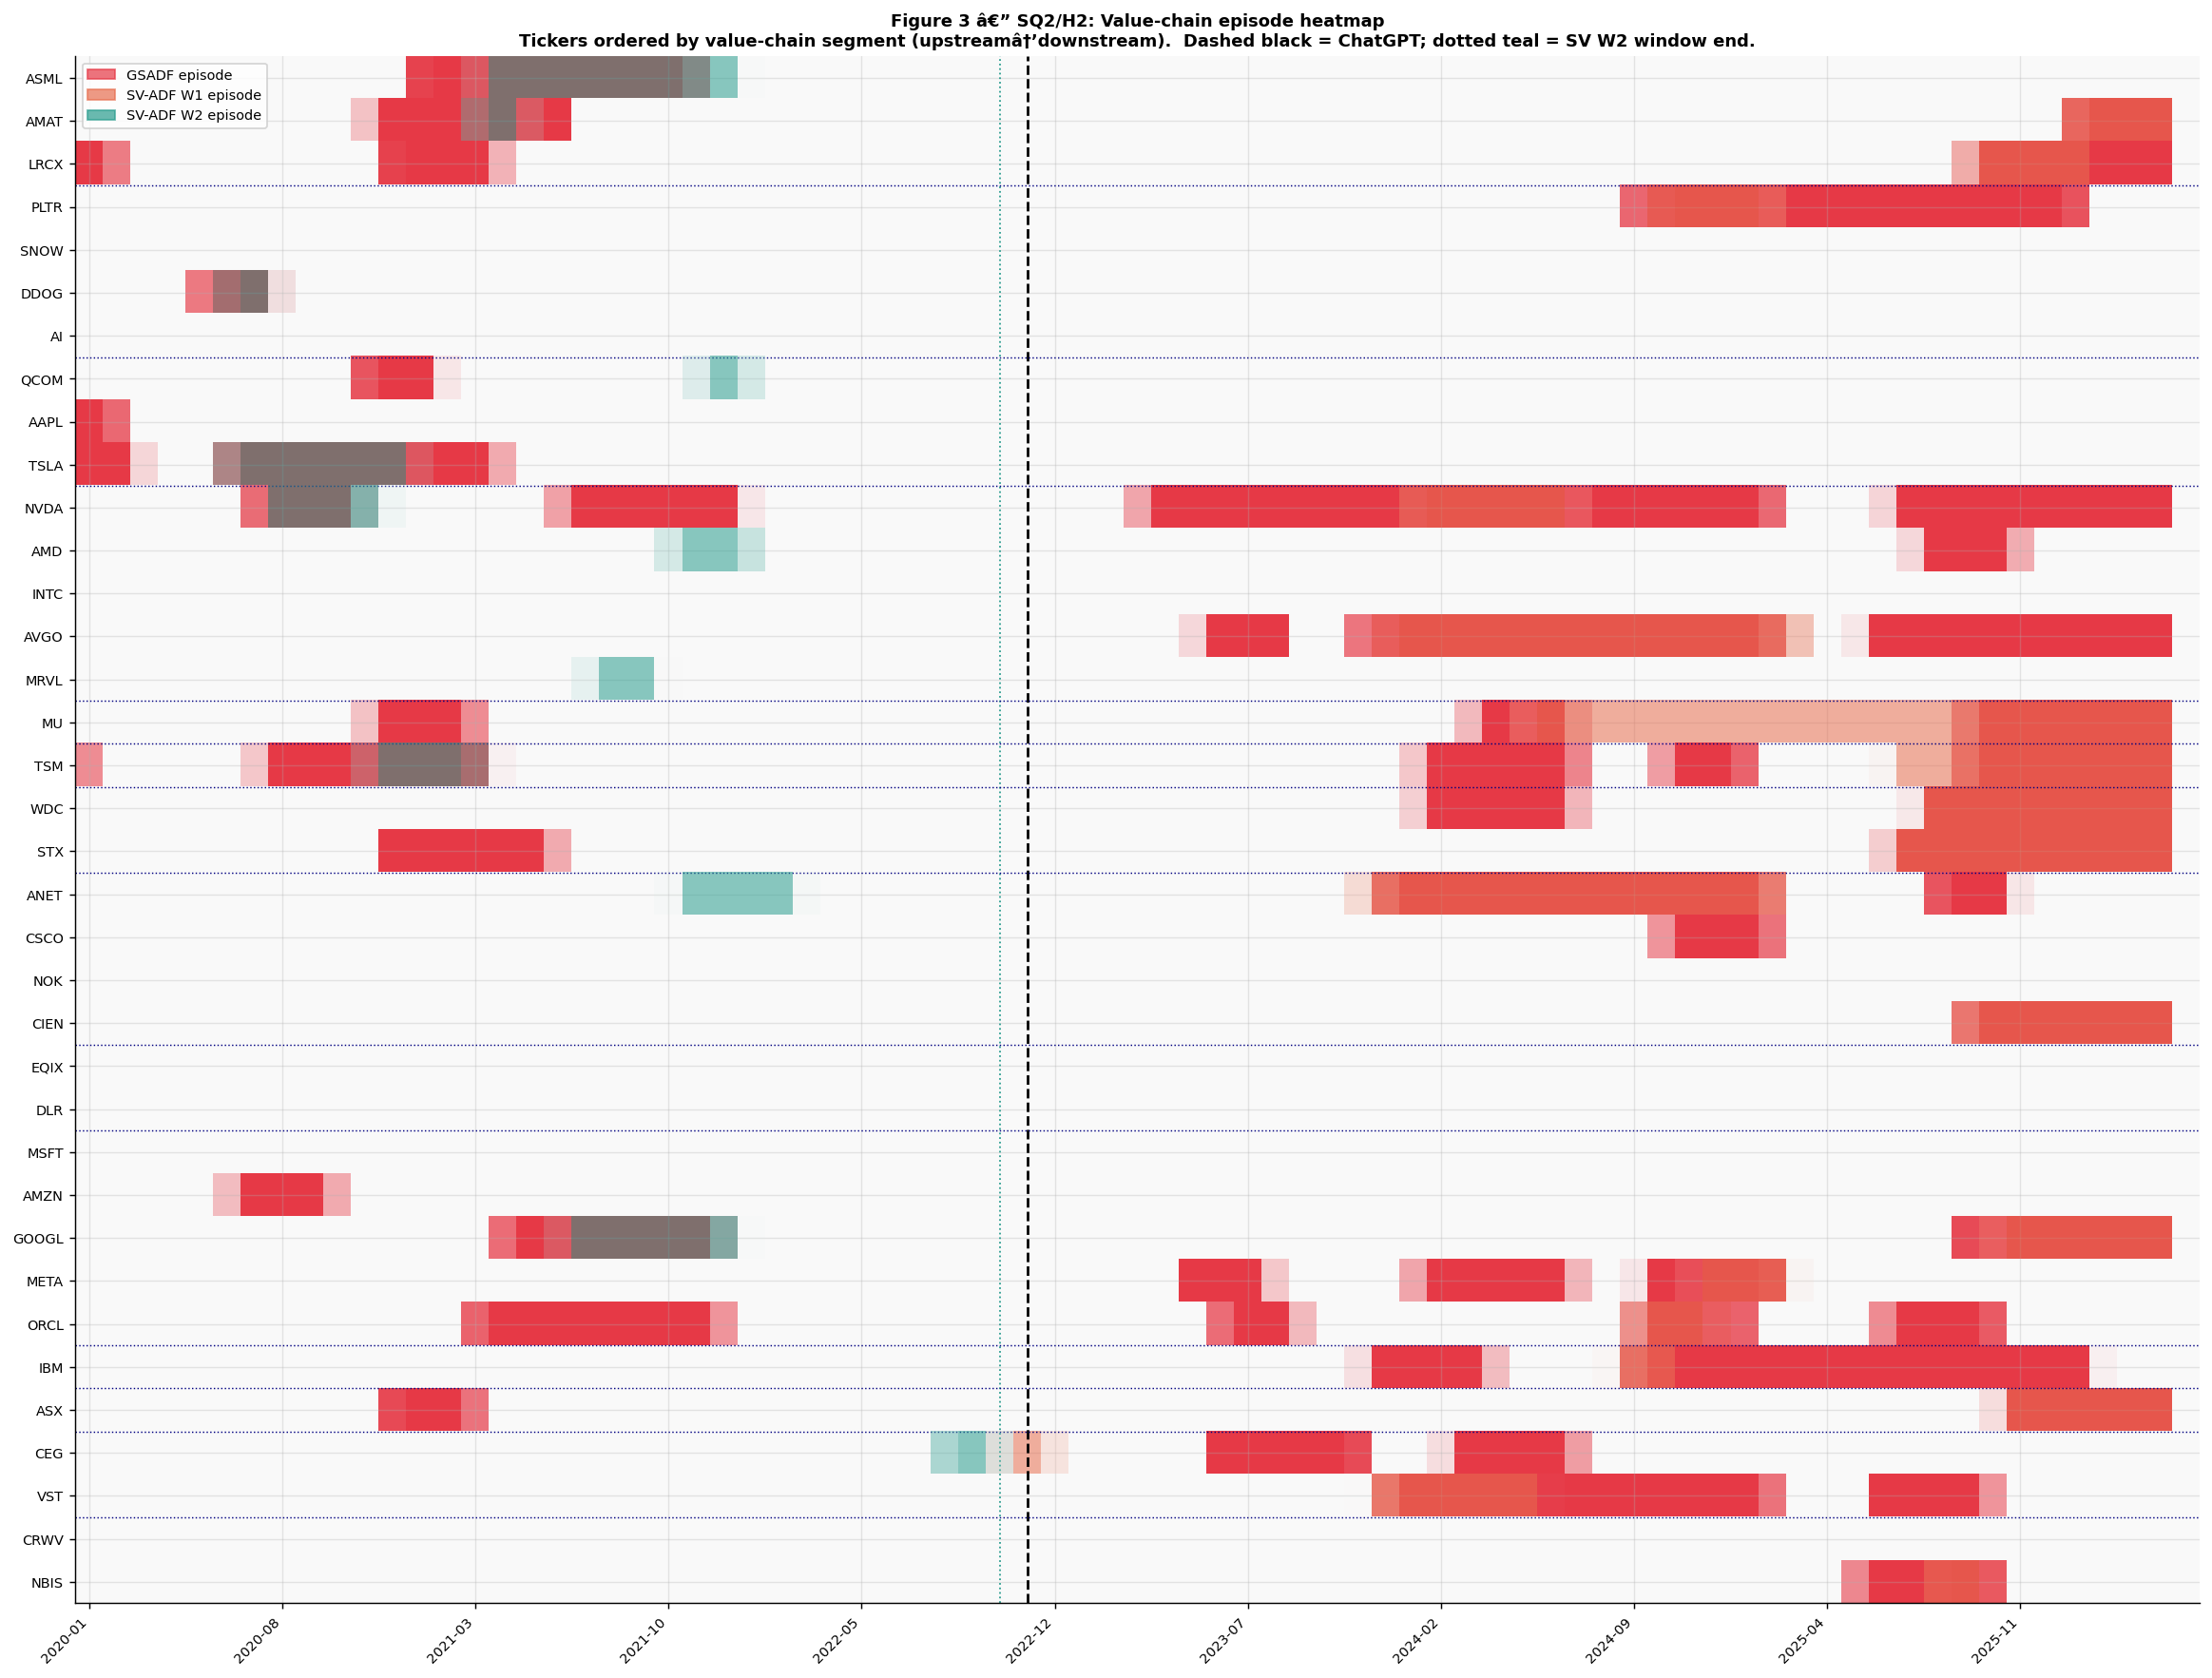

In [72]:
eq_master = master[master["is_equity"] & master["gsadf_stat"].notna()].copy()

if not eq_master.empty and not prices.empty:
    date_range = pd.date_range(settings.FIXED_START, settings.FIXED_END, freq="B")
    sorted_tickers = eq_master.sort_values("segment")["ticker"].tolist()
    seg_of = {row["ticker"]: row["segment"] for _, row in eq_master.iterrows()}

    def _ep_matrix(tickers, episodes_fn):
        """Build a binary date×ticker matrix where 1 = in episode."""
        mat = pd.DataFrame(0, index=date_range, columns=tickers)
        for tk in tickers:
            for ep_start, ep_end in episodes_fn(tk):
                mask = (mat.index >= ep_start) & (mat.index <= ep_end)
                mat.loc[mask, tk] = 1
        return mat.resample("ME").mean()

    def _gsadf_eps(tk):
        r = load_gsadf(tk)
        if not r: return []
        return [(pd.Timestamp(e["start"]), pd.Timestamp(e["end"]))
                for e in r["summary"]["episodes"]]

    def _sv_eps(tk, win):
        r = load_svadf(tk, *win)
        if not r: return []
        ep = r["summary"]["episode"]
        return [(pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"]))] if ep else []

    gsadf_m = _ep_matrix(sorted_tickers, _gsadf_eps)
    sv1_m   = _ep_matrix(sorted_tickers, lambda tk: _sv_eps(tk, SVADF_WIN1))
    sv2_m   = _ep_matrix(sorted_tickers, lambda tk: _sv_eps(tk, SVADF_WIN2))

    # Segment dividers
    segs = [seg_of[t] for t in sorted_tickers]
    dividers = [j for j in range(1, len(segs)) if segs[j] != segs[j-1]]

    fig, ax = plt.subplots(figsize=(18, max(5, len(sorted_tickers) * 0.38)))

    # Base layer: GSADF
    gsadf_cmap = LinearSegmentedColormap.from_list("gs", ["#f9f9f9", GSADF_COLOR])
    ax.imshow(gsadf_m.T.values, aspect="auto", cmap=gsadf_cmap, vmin=0, vmax=1,
              interpolation="nearest", zorder=1)

    # Overlay: SV-ADF W1 (orange, semi-transparent)
    sv1_cmap = LinearSegmentedColormap.from_list("sv1", [(1,1,1,0), (*[c/255 for c in (231,111,81)], 0.55)])
    ax.imshow(sv1_m.T.values, aspect="auto", cmap=sv1_cmap, vmin=0, vmax=1,
              interpolation="nearest", zorder=2)

    # Overlay: SV-ADF W2 (teal, semi-transparent)
    sv2_cmap = LinearSegmentedColormap.from_list("sv2", [(1,1,1,0), (*[c/255 for c in (42,157,143)], 0.55)])
    ax.imshow(sv2_m.T.values, aspect="auto", cmap=sv2_cmap, vmin=0, vmax=1,
              interpolation="nearest", zorder=3)

    # X-axis dates
    n_d = len(gsadf_m)
    step = max(1, n_d // 10)
    ax.set_xticks(range(0, n_d, step))
    ax.set_xticklabels([gsadf_m.index[i].strftime("%Y-%m") for i in range(0, n_d, step)],
                       rotation=45, ha="right", fontsize=8)

    # Y-axis tickers
    ax.set_yticks(range(len(sorted_tickers)))
    ax.set_yticklabels(sorted_tickers, fontsize=8)

    # ChatGPT line
    cg_i = gsadf_m.index.searchsorted(CHATGPT)
    ax.axvline(cg_i, color="black", lw=1.5, ls="--")

    # SV-ADF W2 end line (pre-ChatGPT window boundary)
    sv2_end_i = gsadf_m.index.searchsorted(pd.Timestamp(SVADF_WIN2[1]))
    ax.axvline(sv2_end_i, color=W2_COLOR, lw=1, ls=":")

    # Segment dividers
    for d in dividers:
        ax.axhline(d - 0.5, color="navy", lw=0.8, ls=":")

    legend_patches = [
        mpatches.Patch(color=GSADF_COLOR, alpha=0.7, label="GSADF episode"),
        mpatches.Patch(color=W1_COLOR,    alpha=0.7, label=f"SV-ADF W1 episode"),
        mpatches.Patch(color=W2_COLOR,    alpha=0.7, label=f"SV-ADF W2 episode"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="upper left")
    ax.set_title(
        "Figure 3 — SQ2/H2: Value-chain episode heatmap\n"
        "Tickers ordered by value-chain segment (upstream→downstream).  "
        "Dashed black = ChatGPT; dotted teal = SV W2 window end.",
        fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGDIR / "fig3_valuechain_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Need equity GSADF results and prices.")

---
## Figure 4 — SQ2 / H2: Segment episode-rate bar chart

For each segment, three grouped bars show the share of tickers with at least one detected episode:
GSADF (red), SV-ADF W1 (orange), SV-ADF W2 (teal). Colour-codes segments by value-chain position
(upstream segs 1–4, midstream 5–8, downstream 9–11). Tests H2: upstream AI-hardware segments
should show higher episode rates than downstream or control segments.

Saves to `outputs/figures/thesis/fig4_segment_episoderate.png`.

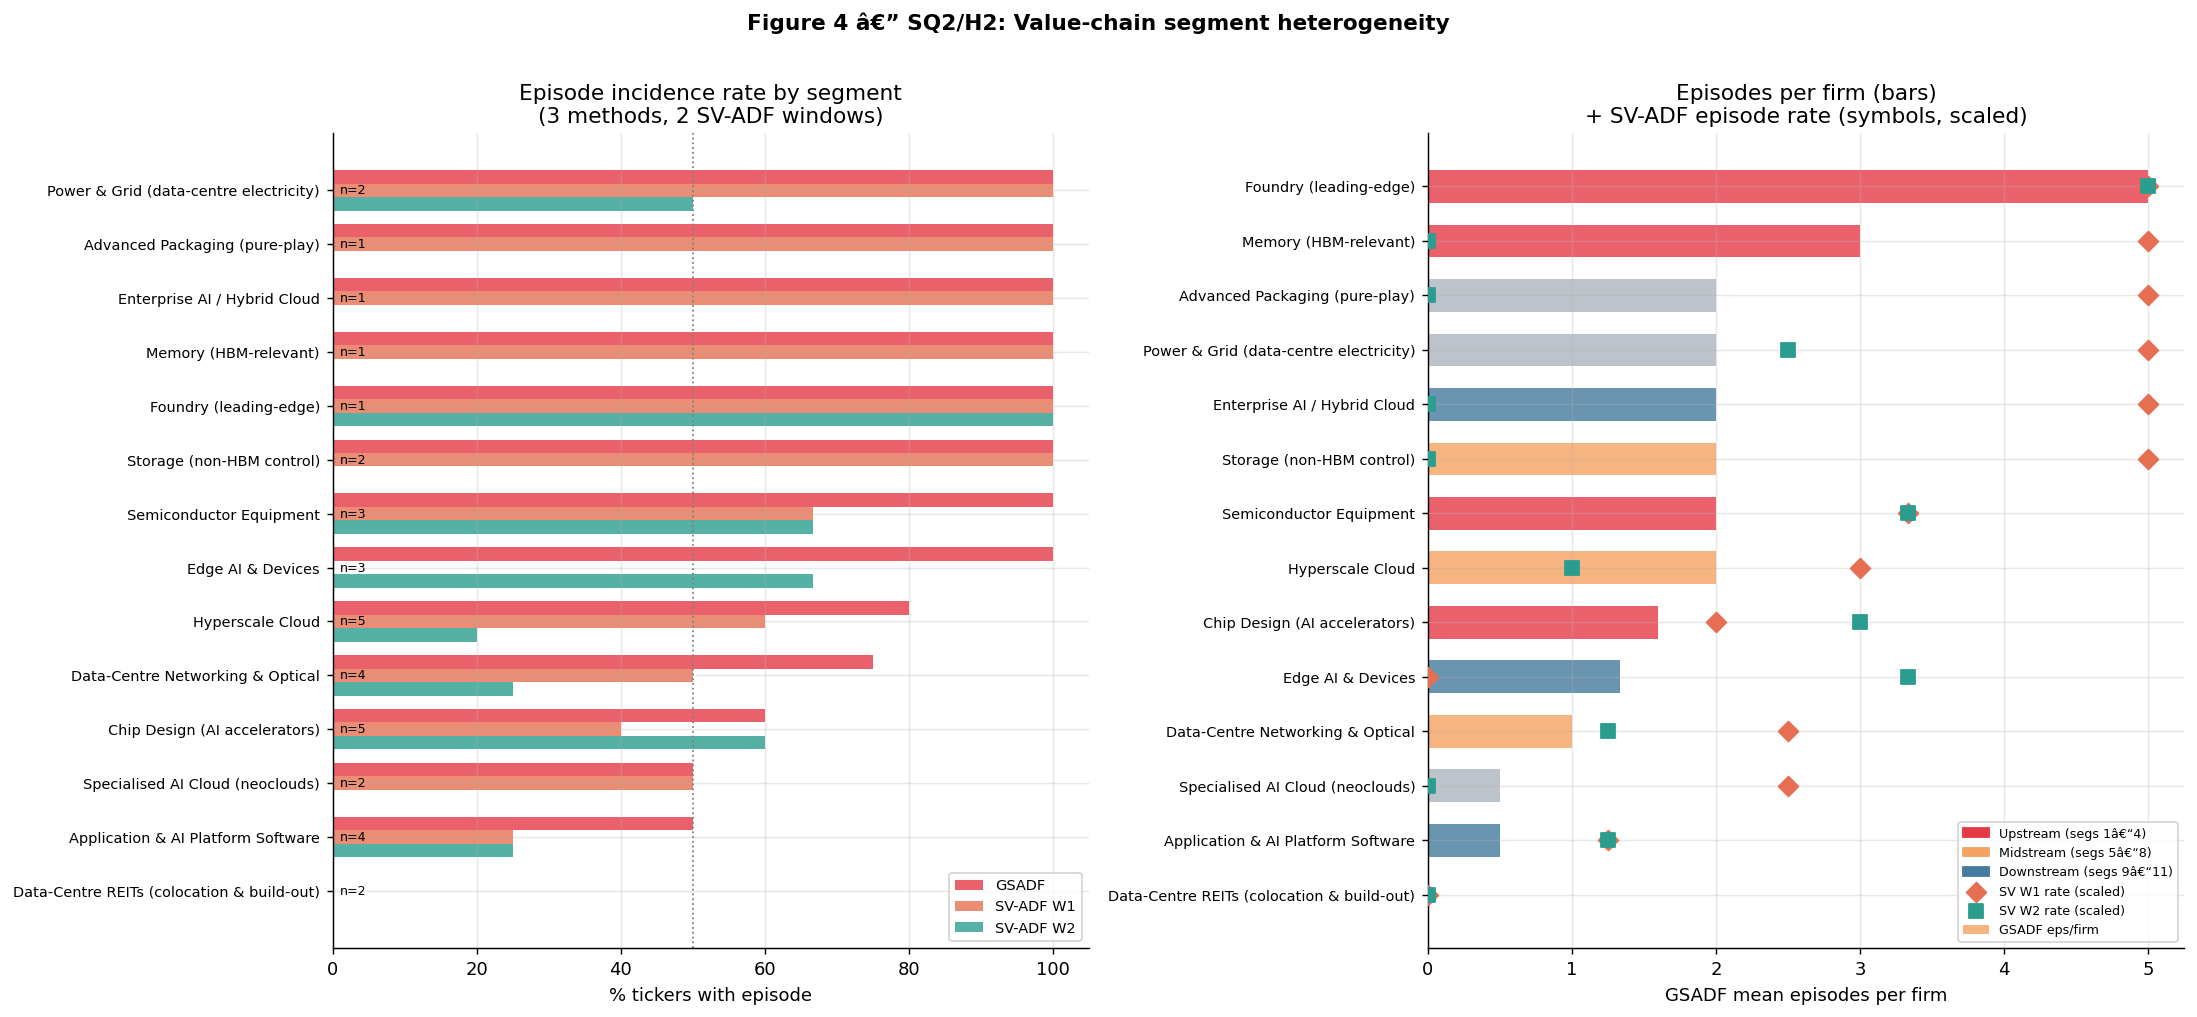

,Segment,N,GSADF rate,SV W1 rate,SV W2 rate,GSADF eps/firm
8,7. Data-Centre REITs (colocation & build-out),2,0.00,0.000000,0.000000,0.000000
1,10. Application & AI Platform Software,4,0.50,0.250000,0.250000,0.500000
13,P. Specialised AI Cloud (neoclouds),2,0.50,0.500000,0.000000,0.500000
3,2. Chip Design (AI accelerators),5,0.60,0.400000,0.600000,1.600000
7,6. Data-Centre Networking & Optical,4,0.75,0.500000,0.250000,1.000000
9,8. Hyperscale Cloud,5,0.80,0.600000,0.200000,2.000000
2,11. Edge AI & Devices,3,1.00,0.000000,0.666667,1.333333
0,1. Semiconductor Equipment,3,1.00,0.666667,0.666667,2.000000
6,5. Storage (non-HBM control),2,1.00,1.000000,0.000000,2.000000
5,4. Foundry (leading-edge),1,1.00,1.000000,1.000000,5.000000


In [73]:
eq_m = master[master["is_equity"] & master["gsadf_stat"].notna()].copy()

def seg_colour(seg):
    p = seg.split(".")[0].strip()
    if p.isdigit():
        n = int(p)
        if n <= 4:  return "#e63946"
        if n <= 8:  return "#f4a261"
        return "#457b9d"
    return "#adb5bd"

seg_stats = []
for seg, grp in eq_m.groupby("segment"):
    n   = len(grp)
    seg_stats.append({
        "Segment"       : seg,
        "N"             : n,
        "GSADF rate"    : grp["gsadf_n_ep"].gt(0).mean(),
        "SV W1 rate"    : grp["sv_w1_has_ep"].mean(),
        "SV W2 rate"    : grp["sv_w2_has_ep"].mean(),
        "GSADF eps/firm": grp["gsadf_n_ep"].mean(),
    })
sdf = pd.DataFrame(seg_stats).sort_values("GSADF rate", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(17, max(6, len(sdf) * 0.55)))
y   = np.arange(len(sdf))
h   = 0.25
short = [s.split(".", 1)[1].strip() if "." in s else s for s in sdf["Segment"]]

# Left: episode incidence rate (share of tickers with ≥ 1 episode)
ax = axes[0]
ax.barh(y + h,    sdf["GSADF rate"]  * 100, h, color=GSADF_COLOR, alpha=0.8, label="GSADF")
ax.barh(y,        sdf["SV W1 rate"]  * 100, h, color=W1_COLOR,    alpha=0.8, label="SV-ADF W1")
ax.barh(y - h,    sdf["SV W2 rate"]  * 100, h, color=W2_COLOR,    alpha=0.8, label="SV-ADF W2")
ax.set_yticks(y)
ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel("% tickers with episode")
ax.set_title("Episode incidence rate by segment\n(3 methods, 2 SV-ADF windows)")
ax.axvline(50, color="grey", ls=":", lw=1)
ax.legend(fontsize=8)
for ix, n in enumerate(sdf["N"]):
    ax.text(1, ix, f"n={n}", va="center", fontsize=7)

# Right: GSADF episodes per firm + SV-ADF episode presence as dots
sdf2 = sdf.sort_values("GSADF eps/firm", ascending=True)
short2 = [s.split(".", 1)[1].strip() if "." in s else s for s in sdf2["Segment"]]
y2 = np.arange(len(sdf2))
ax2 = axes[1]
ax2.barh(y2, sdf2["GSADF eps/firm"], color=[seg_colour(s) for s in sdf2["Segment"]],
         alpha=0.8, height=0.6, label="GSADF eps/firm")
# Overlay SV-ADF W1 rate as orange dots
ax2.scatter(sdf2["SV W1 rate"] * sdf2["GSADF eps/firm"].max(),
            y2, color=W1_COLOR, s=60, zorder=4, label="SV W1 rate (scaled)", marker="D")
ax2.scatter(sdf2["SV W2 rate"] * sdf2["GSADF eps/firm"].max(),
            y2, color=W2_COLOR, s=60, zorder=4, label="SV W2 rate (scaled)", marker="s")
ax2.set_yticks(y2)
ax2.set_yticklabels(short2, fontsize=8)
ax2.set_xlabel("GSADF mean episodes per firm")
ax2.set_title("Episodes per firm (bars)\n+ SV-ADF episode rate (symbols, scaled)")
ax2.legend(fontsize=7)

legend_patches = [
    mpatches.Patch(color="#e63946", label="Upstream (segs 1–4)"),
    mpatches.Patch(color="#f4a261", label="Midstream (segs 5–8)"),
    mpatches.Patch(color="#457b9d", label="Downstream (segs 9–11)"),
]
axes[1].legend(handles=legend_patches + axes[1].get_legend_handles_labels()[0][:3],
               fontsize=7, loc="lower right")

plt.suptitle("Figure 4 — SQ2/H2: Value-chain segment heterogeneity",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "fig4_segment_episoderate.png", dpi=150, bbox_inches="tight")
plt.show()
display(sdf)

---
## Figure 5 — SQ3 / H4: Method agreement (SADF × GSADF × SV-ADF W1 × SV-ADF W2)

Pairwise agreement matrix across all four methods, plus a bar chart comparing GSADF vs SV-ADF
episode counts per ticker. H4 decision rule: GSADF episode count > SV-ADF W1 episode count
for each ticker on the common sample (GSADF is more selective given the longer window).

Saves to `outputs/figures/thesis/fig5_method_agreement.png`.

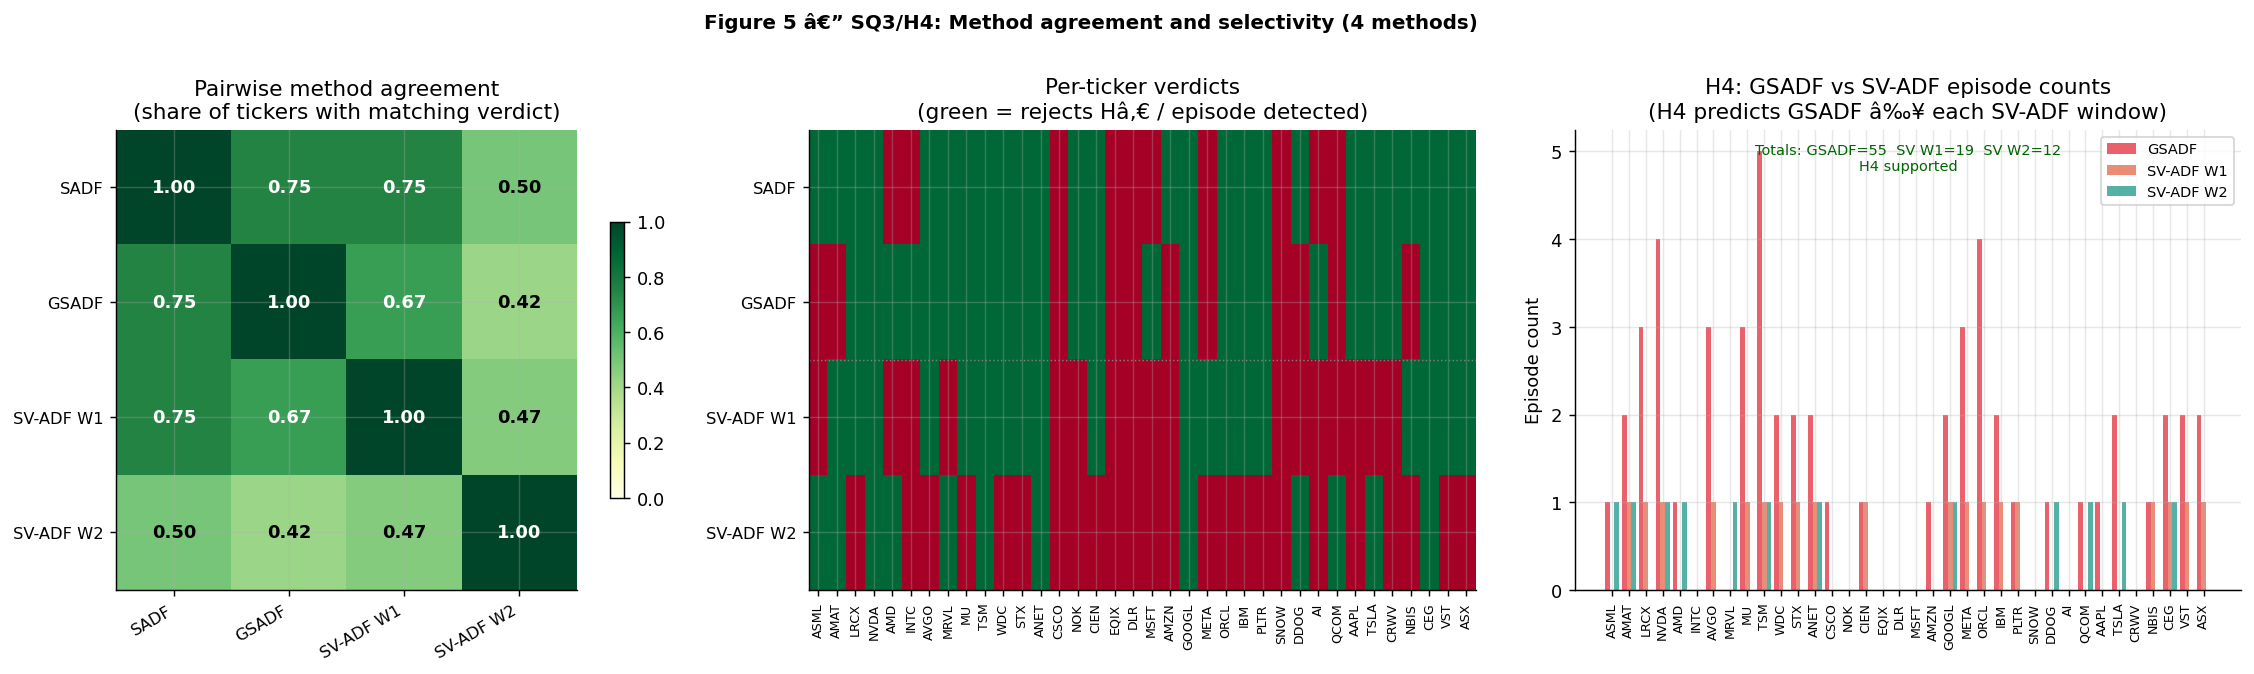

In [74]:
eq_m = master[master["is_equity"]].copy()
eq_m["SADF"]      = eq_m["sadf_signal"].astype(int)
eq_m["GSADF"]     = eq_m["gsadf_reject"].astype(int)
eq_m["SV-ADF W1"] = eq_m["sv_w1_has_ep"].astype(int)
eq_m["SV-ADF W2"] = eq_m["sv_w2_has_ep"].astype(int)
methods = ["SADF", "GSADF", "SV-ADF W1", "SV-ADF W2"]
valid   = eq_m[eq_m["gsadf_stat"].notna()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Pairwise agreement matrix ─────────────────────────────────────────────────
ax = axes[0]
amat = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m in methods:
    amat.loc[m, m] = 1.0
for m1, m2 in combinations(methods, 2):
    c = valid[m1].notna() & valid[m2].notna()
    v = (valid.loc[c, m1] == valid.loc[c, m2]).mean() if c.sum() else np.nan
    amat.loc[m1, m2] = amat.loc[m2, m1] = v

im = ax.imshow(amat.values.astype(float), cmap="YlGn", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(methods, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(methods, fontsize=9)
for i in range(4):
    for j in range(4):
        v = amat.iloc[i,j]
        ax.text(j, i, f"{v:.2f}" if not np.isnan(v) else "N/A",
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white" if v > 0.65 else "black")
plt.colorbar(im, ax=ax, shrink=0.6)
ax.set_title("Pairwise method agreement\n(share of tickers with matching verdict)")

# ── Per-ticker verdict grid ────────────────────────────────────────────────────
ax2 = axes[1]
vgrid = valid[["ticker"] + methods].set_index("ticker").fillna(0).astype(int)
im2 = ax2.imshow(vgrid.T.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax2.set_xticks(range(len(vgrid)))
ax2.set_xticklabels(vgrid.index, rotation=90, fontsize=7)
ax2.set_yticks(range(4))
ax2.set_yticklabels(methods, fontsize=9)
ax2.set_title("Per-ticker verdicts\n(green = rejects H₀ / episode detected)")
# Draw horizontal line separating the two SV-ADF rows
ax2.axhline(1.5, color="grey", lw=0.8, ls=":")

# ── H4: GSADF vs SV-ADF episode counts ────────────────────────────────────────
ax3 = axes[2]
tks = valid["ticker"].tolist()
gs_c  = [valid.loc[valid["ticker"]==t, "gsadf_n_ep"].values[0] for t in tks]
sv1_c = [int(valid.loc[valid["ticker"]==t, "sv_w1_has_ep"].values[0]) for t in tks]
sv2_c = [int(valid.loc[valid["ticker"]==t, "sv_w2_has_ep"].values[0]) for t in tks]
x = np.arange(len(tks)); w = 0.28
ax3.bar(x - w, gs_c,  w, label="GSADF",      color=GSADF_COLOR, alpha=0.8)
ax3.bar(x,     sv1_c, w, label="SV-ADF W1",  color=W1_COLOR,    alpha=0.8)
ax3.bar(x + w, sv2_c, w, label="SV-ADF W2",  color=W2_COLOR,    alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(tks, rotation=90, fontsize=7)
ax3.set_ylabel("Episode count")
ax3.set_title("H4: GSADF vs SV-ADF episode counts\n(H4 predicts GSADF ≥ each SV-ADF window)")
ax3.legend(fontsize=8)
tot_gs, tot_sv1, tot_sv2 = sum(gs_c), sum(sv1_c), sum(sv2_c)
h4 = "H4 supported" if tot_gs > tot_sv1 else "H4 not supported"
ax3.text(0.5, 0.97,
         f"Totals: GSADF={tot_gs}  SV W1={tot_sv1}  SV W2={tot_sv2}\n{h4}",
         transform=ax3.transAxes, ha="center", va="top", fontsize=8,
         color="darkgreen" if tot_gs > tot_sv1 else "crimson")

plt.suptitle("Figure 5 — SQ3/H4: Method agreement and selectivity (4 methods)",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "fig5_method_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Figure 6 — SQ4 / H6: Commodity propagation

GSADF statistics and episode bars for all commodity tickers, grouped by type
(AI-relevant metals, energy, placebo agriculture, benchmark indices).
Both SV-ADF windows are shown on the **same panel** for each group.
Tests H6: AI-relevant commodities (copper, energy) show explosive behaviour
prior to or concurrent with equity bubbles; placebo commodities do not.

Saves to `outputs/figures/thesis/fig6_commodity_propagation.png`.

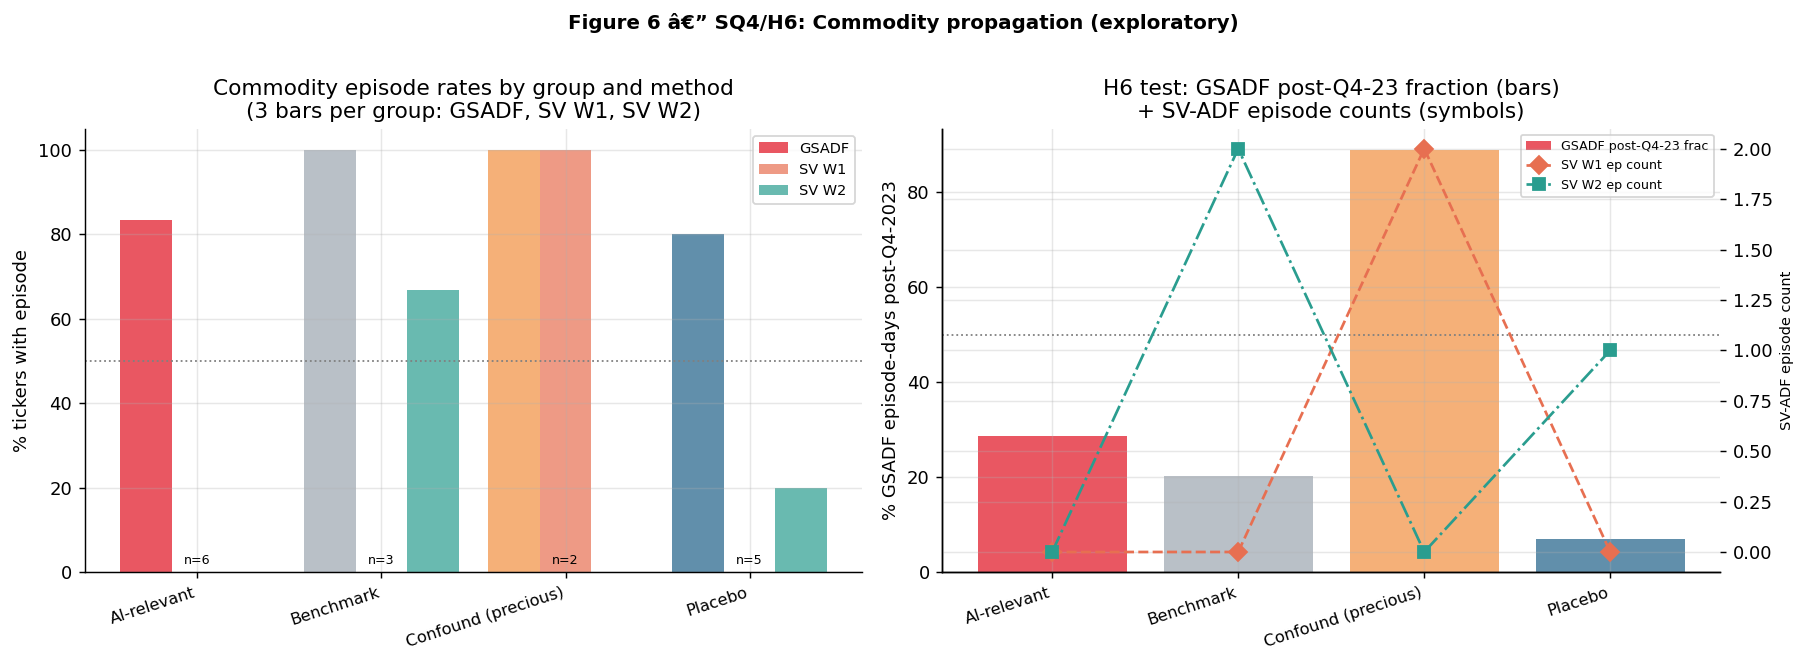

,Group,N,GSADF ep rate,SV W1 ep rate,SV W2 ep rate,Post-Q4-23 frac,SV W1 ep count,SV W2 ep count
0,AI-relevant,6,0.833333,0.0,0.000000,0.287568,0,0
1,Benchmark,3,1.000000,0.0,0.666667,0.201601,0,2
2,Confound (precious),2,1.000000,1.0,0.000000,0.890160,2,0
3,Placebo,5,0.800000,0.0,0.200000,0.069202,0,1


In [75]:
comm_m = master[master["is_commodity"] & master["gsadf_stat"].notna()].copy()

def comm_class(seg):
    sl = seg.lower()
    if "ai-relevant" in sl: return "AI-relevant"
    if "placebo"     in sl: return "Placebo"
    if "confound"    in sl: return "Confound (precious)"
    return "Benchmark"

comm_m["group"] = comm_m["segment"].apply(comm_class)
Q4_2023 = pd.Timestamp("2023-10-01")

def ep_days_split(eps, cutoff):
    pre = post = 0
    for ep in eps:
        s, e = pd.Timestamp(ep["start"]), pd.Timestamp(ep["end"])
        if   e < cutoff: pre  += ep["duration_days"]
        elif s >= cutoff: post += ep["duration_days"]
        else:
            pre  += (cutoff - s).days
            post += (e - cutoff).days
    return pre, post

group_stats = []
for grp_name, gdf in comm_m.groupby("group"):
    all_gsadf_eps = [ep for eps in gdf["gsadf_episodes"] for ep in eps]
    pre_g, post_g = ep_days_split(all_gsadf_eps, Q4_2023)
    tot_g = pre_g + post_g
    sv1_eps = []
    sv2_eps = []
    for _, row in gdf.iterrows():
        if row["sv_w1_episode"]: sv1_eps.append(row["sv_w1_episode"])
        if row["sv_w2_episode"]: sv2_eps.append(row["sv_w2_episode"])
    group_stats.append({
        "Group"            : grp_name,
        "N"                : len(gdf),
        "GSADF ep rate"    : gdf["gsadf_n_ep"].gt(0).mean(),
        "SV W1 ep rate"    : gdf["sv_w1_has_ep"].mean(),
        "SV W2 ep rate"    : gdf["sv_w2_has_ep"].mean(),
        "Post-Q4-23 frac"  : post_g / tot_g if tot_g else 0,
        "SV W1 ep count"   : len(sv1_eps),
        "SV W2 ep count"   : len(sv2_eps),
    })

gdf_stat = pd.DataFrame(group_stats)
grp_colors = {"AI-relevant": GSADF_COLOR, "Placebo": "#457b9d",
              "Confound (precious)": "#f4a261", "Benchmark": "#adb5bd"}
x = np.arange(len(gdf_stat)); w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: episode incidence rate, 3 methods per group
ax = axes[0]
ax.bar(x - w, gdf_stat["GSADF ep rate"]*100, w,
       color=[grp_colors.get(g,"grey") for g in gdf_stat["Group"]], alpha=0.85, label="GSADF")
ax.bar(x,     gdf_stat["SV W1 ep rate"]*100, w, color=W1_COLOR, alpha=0.7, label="SV W1")
ax.bar(x + w, gdf_stat["SV W2 ep rate"]*100, w, color=W2_COLOR, alpha=0.7, label="SV W2")
ax.set_xticks(x)
ax.set_xticklabels(gdf_stat["Group"], rotation=18, ha="right", fontsize=9)
ax.set_ylabel("% tickers with episode")
ax.set_title("Commodity episode rates by group and method\n(3 bars per group: GSADF, SV W1, SV W2)")
ax.legend(fontsize=8)
ax.axhline(50, color="grey", ls=":", lw=1)
for xi, n in zip(x, gdf_stat["N"]):
    ax.text(xi, 2, f"n={n}", ha="center", fontsize=7)

# Right: post-Q4-2023 fraction (GSADF) + SV episode counts
ax2 = axes[1]
ax2.bar(x, gdf_stat["Post-Q4-23 frac"]*100,
        color=[grp_colors.get(g,"grey") for g in gdf_stat["Group"]], alpha=0.85, label="GSADF post-Q4-23 frac")
ax2_r = ax2.twinx()
ax2_r.plot(x, gdf_stat["SV W1 ep count"], color=W1_COLOR, marker="D",
           ls="--", ms=7, label="SV W1 ep count")
ax2_r.plot(x, gdf_stat["SV W2 ep count"], color=W2_COLOR, marker="s",
           ls="-.", ms=7, label="SV W2 ep count")
ax2_r.set_ylabel("SV-ADF episode count", fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(gdf_stat["Group"], rotation=18, ha="right", fontsize=9)
ax2.set_ylabel("% GSADF episode-days post-Q4-2023")
ax2.set_title("H6 test: GSADF post-Q4-23 fraction (bars)\n+ SV-ADF episode counts (symbols)")
ax2.axhline(50, color="grey", ls=":", lw=1)
lines1, lbs1 = ax2.get_legend_handles_labels()
lines2, lbs2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, lbs1+lbs2, fontsize=7)

plt.suptitle("Figure 6 — SQ4/H6: Commodity propagation (exploratory)",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "fig6_commodity_propagation.png", dpi=150, bbox_inches="tight")
plt.show()
display(gdf_stat)

---
## Figure 7 — SQ5 / H5: Historical validation

Out-of-sample validation on three known bubble/non-bubble cases:
1. **NASDAQ dot-com** (1994–2002): GSADF should detect explosive behaviour in 1999–2000
2. **S&P 500 GFC** (2003–2009): negative control — GSADF should *not* reject (GFC is a credit/housing bubble)
3. **Case-Shiller housing index** (2000–2009): GSADF should detect the 2004–2006 housing boom

Cell below downloads historical prices, runs GSADF with MC critical values, and plots
a 2-column layout (time series + timing bar) for each case.

Saves to `outputs/figures/thesis/fig7_historical_validation.png`.

In [87]:
from src.io.data          import download_prices
from src.methods.gsadf    import gsadf as run_gsadf_method, minimum_window
from src.methods.episodes import detect_bsadf_episodes
from src.monte_carlo      import get_critical_values
import io, urllib.request

# Each entry is a list of (start, end) reference windows.
# BTC episodes from:
#   Li et al. (2021, pub. 4 Jan 2021) — five episodes
#   Oldani, Bruno & Signorelli (2025)  — three episodes
KNOWN_EP = {
    "NASDAQ_dotcom": [(pd.Timestamp("1995-06-01"), pd.Timestamp("2000-09-01"))],
    "BTC_2017"     : [
        (pd.Timestamp("2016-06-08"), pd.Timestamp("2016-06-18")),
        (pd.Timestamp("2016-12-30"), pd.Timestamp("2017-01-15")),
        (pd.Timestamp("2017-02-22"), pd.Timestamp("2017-03-07")),
        (pd.Timestamp("2017-04-27"), pd.Timestamp("2017-07-05")),
        (pd.Timestamp("2017-07-15"), pd.Timestamp("2018-01-09")),
        (pd.Timestamp("2018-11-24"), pd.Timestamp("2018-12-08")),
        (pd.Timestamp("2019-05-11"), pd.Timestamp("2019-06-28")),
        (pd.Timestamp("2020-12-19"), pd.Timestamp("2021-03-13")),
    ],
}
HOUSING_KNOWN_EP = [(pd.Timestamp("2002-06-01"), pd.Timestamp("2006-07-01"))]

val_res = {}

for case_name, case in settings.VALIDATION_CASES.items():
    if case["ticker"] == "^GSPC":
        print("   Skipping " + case_name + " (S&P 500 removed from loop)")
        continue
    tk      = case["ticker"]
    c_start = case["start"]
    c_end   = case["end"]
    print("-- " + case_name + ": downloading " + tk + " [" + c_start + " -> " + c_end + "] ...")
    df  = download_prices([tk], start=c_start, end=c_end)
    col = next((c for c in [tk, tk.lstrip("^"), tk.upper(), tk.lstrip("^").upper()]
                if c in df.columns), None)
    if col is None or df[col].dropna().empty:
        print("   [SKIP]"); continue
    s = df[col].dropna().rename(tk)
    print("   T=" + str(len(s)) + "  " + str(s.index[0].date()) + " -> " + str(s.index[-1].date()))
    T, mw    = len(s), minimum_window(len(s))
    g        = run_gsadf_method(s.to_numpy(), min_window=mw)
    cv       = get_critical_values(T=T, min_window=mw, nrep=settings.GSADF_MC_REPS,
                                   seed=settings.SEED, quantiles=(0.95,), verbose=False)
    cv_val, cv_path = cv["gsadf"][0.95], cv["bsadf_path"][0.95]
    bsadf_dt = s.index[mw - 1:]
    eps      = detect_bsadf_episodes(g["path"], cv_path, bsadf_dt,
                                     min_duration=21, merge_gap=21)
    stat     = g["statistic"]
    verdict  = "REJECT" if stat > cv_val else "fail to reject"
    print("   stat=" + str(round(stat, 2)) + "  cv=" + str(round(cv_val, 2)) + "  " + verdict + "  episodes=" + str(len(eps)))
    for ep in eps:
        print("     " + str(ep["start"].date()) + " -> " + str(ep["end"].date()) + "  (" + str(ep["duration_days"]) + "d)")
    val_res[case_name] = {
        "s": s, "bsadf": g["path"], "cv_path": cv_path,
        "dates": bsadf_dt, "eps": eps,
        "stat": stat, "cv": cv_val, "case": case,
    }

# ── S&P 500 GFC (2003-2010): negative control ─────────────────────────────────
# GFC was a housing/credit bubble; explosive dynamics NOT expected in equities.
print("-- SP500_gfc: downloading ^GSPC [2003-01-01 -> 2010-12-31] ...")
try:
    sp_df  = download_prices(["^GSPC"], start="2003-01-01", end="2010-12-31")
    col_sp = next((c for c in ["^GSPC", "GSPC"] if c in sp_df.columns), None)
    if col_sp is None or sp_df[col_sp].dropna().empty:
        raise ValueError("^GSPC column not found")
    sp_s = sp_df[col_sp].dropna().rename("^GSPC")
    print("   T=" + str(len(sp_s)) + "  " + str(sp_s.index[0].date()) + " -> " + str(sp_s.index[-1].date()))
    T, mw    = len(sp_s), minimum_window(len(sp_s))
    g_sp     = run_gsadf_method(sp_s.to_numpy(), min_window=mw)
    cv_sp    = get_critical_values(T=T, min_window=mw, nrep=settings.GSADF_MC_REPS,
                                   seed=settings.SEED, quantiles=(0.95,), verbose=False)
    cv_val_sp, cv_path_sp = cv_sp["gsadf"][0.95], cv_sp["bsadf_path"][0.95]
    bsadf_dt_sp = sp_s.index[mw - 1:]
    eps_sp      = detect_bsadf_episodes(g_sp["path"], cv_path_sp, bsadf_dt_sp,
                                        min_duration=21, merge_gap=21)
    stat_sp    = g_sp["statistic"]
    verdict_sp = "REJECT" if stat_sp > cv_val_sp else "fail to reject"
    print("   stat=" + str(round(stat_sp, 2)) + "  cv=" + str(round(cv_val_sp, 2)) + "  " + verdict_sp + "  episodes=" + str(len(eps_sp)))
    val_res["SP500_gfc"] = {
        "s": sp_s, "bsadf": g_sp["path"], "cv_path": cv_path_sp,
        "dates": bsadf_dt_sp, "eps": eps_sp, "stat": stat_sp, "cv": cv_val_sp,
        "case": {"ticker": "^GSPC", "start": "2003-01-01", "end": "2010-12-31",
                 "expected_dates": "Pre-GFC housing/credit cycle"},
    }
except Exception as e:
    print("   SP500_gfc failed: " + str(e))

# ── Bitcoin (BTC-USD) 2016-2022 ───────────────────────────────────────────────
print("-- Bitcoin (BTC-USD): downloading 2016-2022 ...")
try:
    btc_df = download_prices(["BTC-USD"], start="2016-01-01", end="2022-12-31")
    col_b  = next((c for c in ["BTC-USD", "BTC"] if c in btc_df.columns), None)
    if col_b is None or btc_df[col_b].dropna().empty:
        raise ValueError("BTC-USD column not found")
    btc_s = btc_df[col_b].dropna().rename("BTC-USD")
    print("   T=" + str(len(btc_s)) + "  " + str(btc_s.index[0].date()) + " -> " + str(btc_s.index[-1].date()))
    T, mw    = len(btc_s), minimum_window(len(btc_s))
    g_b      = run_gsadf_method(btc_s.to_numpy(), min_window=mw)
    cv_b     = get_critical_values(T=T, min_window=mw, nrep=settings.GSADF_MC_REPS,
                                   seed=settings.SEED, quantiles=(0.95,), verbose=False)
    cv_val_b, cv_path_b = cv_b["gsadf"][0.95], cv_b["bsadf_path"][0.95]
    bsadf_dt_b = btc_s.index[mw - 1:]
    eps_b      = detect_bsadf_episodes(g_b["path"], cv_path_b, bsadf_dt_b,
                                       min_duration=21, merge_gap=21)
    stat_b     = g_b["statistic"]
    verdict_b  = "REJECT" if stat_b > cv_val_b else "fail to reject"
    print("   stat=" + str(round(stat_b, 2)) + "  cv=" + str(round(cv_val_b, 2)) + "  " + verdict_b + "  episodes=" + str(len(eps_b)))
    for ep in eps_b:
        print("     " + str(ep["start"].date()) + " -> " + str(ep["end"].date()) + "  (" + str(ep["duration_days"]) + "d)")
    val_res["BTC_2017"] = {
        "s": btc_s, "bsadf": g_b["path"], "cv_path": cv_path_b,
        "dates": bsadf_dt_b, "eps": eps_b, "stat": stat_b, "cv": cv_val_b,
        "case": {"ticker": "BTC-USD", "start": "2016-01-01", "end": "2022-12-31",
                 "expected_dates": "Li et al. (2021): 5 episodes 2016-2018 | Oldani et al. (2025): 3 episodes 2018-2021"},
    }
except Exception as e:
    print("   BTC download failed: " + str(e))

# ── Housing (CSUSHPINSA) from FRED ────────────────────────────────────────────
print("-- Housing (CSUSHPINSA): downloading from FRED ...")
try:
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CSUSHPINSA"
    with urllib.request.urlopen(url, timeout=20) as r:
        hdf = pd.read_csv(io.BytesIO(r.read()), parse_dates=["DATE"], index_col="DATE")
    housing_s = hdf["CSUSHPINSA"].dropna().loc["1990":"2012"]
    print("   T=" + str(len(housing_s)) + "  " + str(housing_s.index[0].date()) + " -> " + str(housing_s.index[-1].date()))
    T, mw    = len(housing_s), minimum_window(len(housing_s))
    g_h      = run_gsadf_method(housing_s.to_numpy(), min_window=mw)
    cv_h     = get_critical_values(T=T, min_window=mw, nrep=settings.GSADF_MC_REPS,
                                   seed=settings.SEED, quantiles=(0.95,), verbose=False)
    cv_val_h, cv_path_h = cv_h["gsadf"][0.95], cv_h["bsadf_path"][0.95]
    bsadf_dt_h = housing_s.index[mw - 1:]
    eps_h      = detect_bsadf_episodes(g_h["path"], cv_path_h, bsadf_dt_h,
                                       min_duration=6, merge_gap=6)
    stat_h     = g_h["statistic"]
    verdict_h  = "REJECT" if stat_h > cv_val_h else "fail to reject"
    print("   stat=" + str(round(stat_h, 2)) + "  cv=" + str(round(cv_val_h, 2)) + "  " + verdict_h + "  episodes=" + str(len(eps_h)))
    for ep in eps_h:
        print("     " + str(ep["start"].date()) + " -> " + str(ep["end"].date()) + "  (" + str(ep["duration_days"]) + "d)")
    val_res["Housing_gfc"] = {
        "s": housing_s, "bsadf": g_h["path"], "cv_path": cv_path_h,
        "dates": bsadf_dt_h, "eps": eps_h, "stat": stat_h, "cv": cv_val_h,
        "case": {"ticker": "CSUSHPINSA", "start": "1990-01-01", "end": "2012-12-31",
                  "expected_dates": "PSY (2015): explosive behavior ~2002-2006"},
        "series_label": "Index",
    }
except Exception as e:
    print("   Housing download failed: " + str(e))

print("val_res keys: " + str(list(val_res.keys())))


-- NASDAQ_dotcom: downloading ^IXIC [1990-01-01 -> 2003-12-31] ...
   T=3531  1990-01-02 -> 2003-12-30
   stat=7.04  cv=2.47  REJECT  episodes=8
     1990-08-06 -> 1990-11-09  (95d)
     1991-02-26 -> 1991-06-14  (108d)
     1991-10-16 -> 1991-11-14  (29d)
     1991-12-27 -> 1992-03-26  (90d)
     1992-11-13 -> 1993-03-15  (122d)
     1993-08-18 -> 1994-02-03  (169d)
     1995-05-03 -> 1998-08-26  (1211d)
     1998-11-04 -> 2000-09-22  (688d)
   Skipping SP500_dotcom (S&P 500 removed from loop)
   Skipping SP500_gfc (S&P 500 removed from loop)
-- SP500_gfc: downloading ^GSPC [2003-01-01 -> 2010-12-31] ...
   T=2014  2003-01-02 -> 2010-12-30
   stat=1.68  cv=2.41  fail to reject  episodes=1
-- Bitcoin (BTC-USD): downloading 2016-2022 ...
   T=2556  2016-01-01 -> 2022-12-30
   stat=11.2  cv=2.41  REJECT  episodes=7
     2016-05-28 -> 2016-06-21  (24d)
     2017-02-23 -> 2017-03-15  (20d)
     2017-05-01 -> 2018-01-15  (259d)
     2018-11-24 -> 2018-12-16  (22d)
     2019-05-03 -> 2019-07

Figure 7 -- NEW code (4 panels)


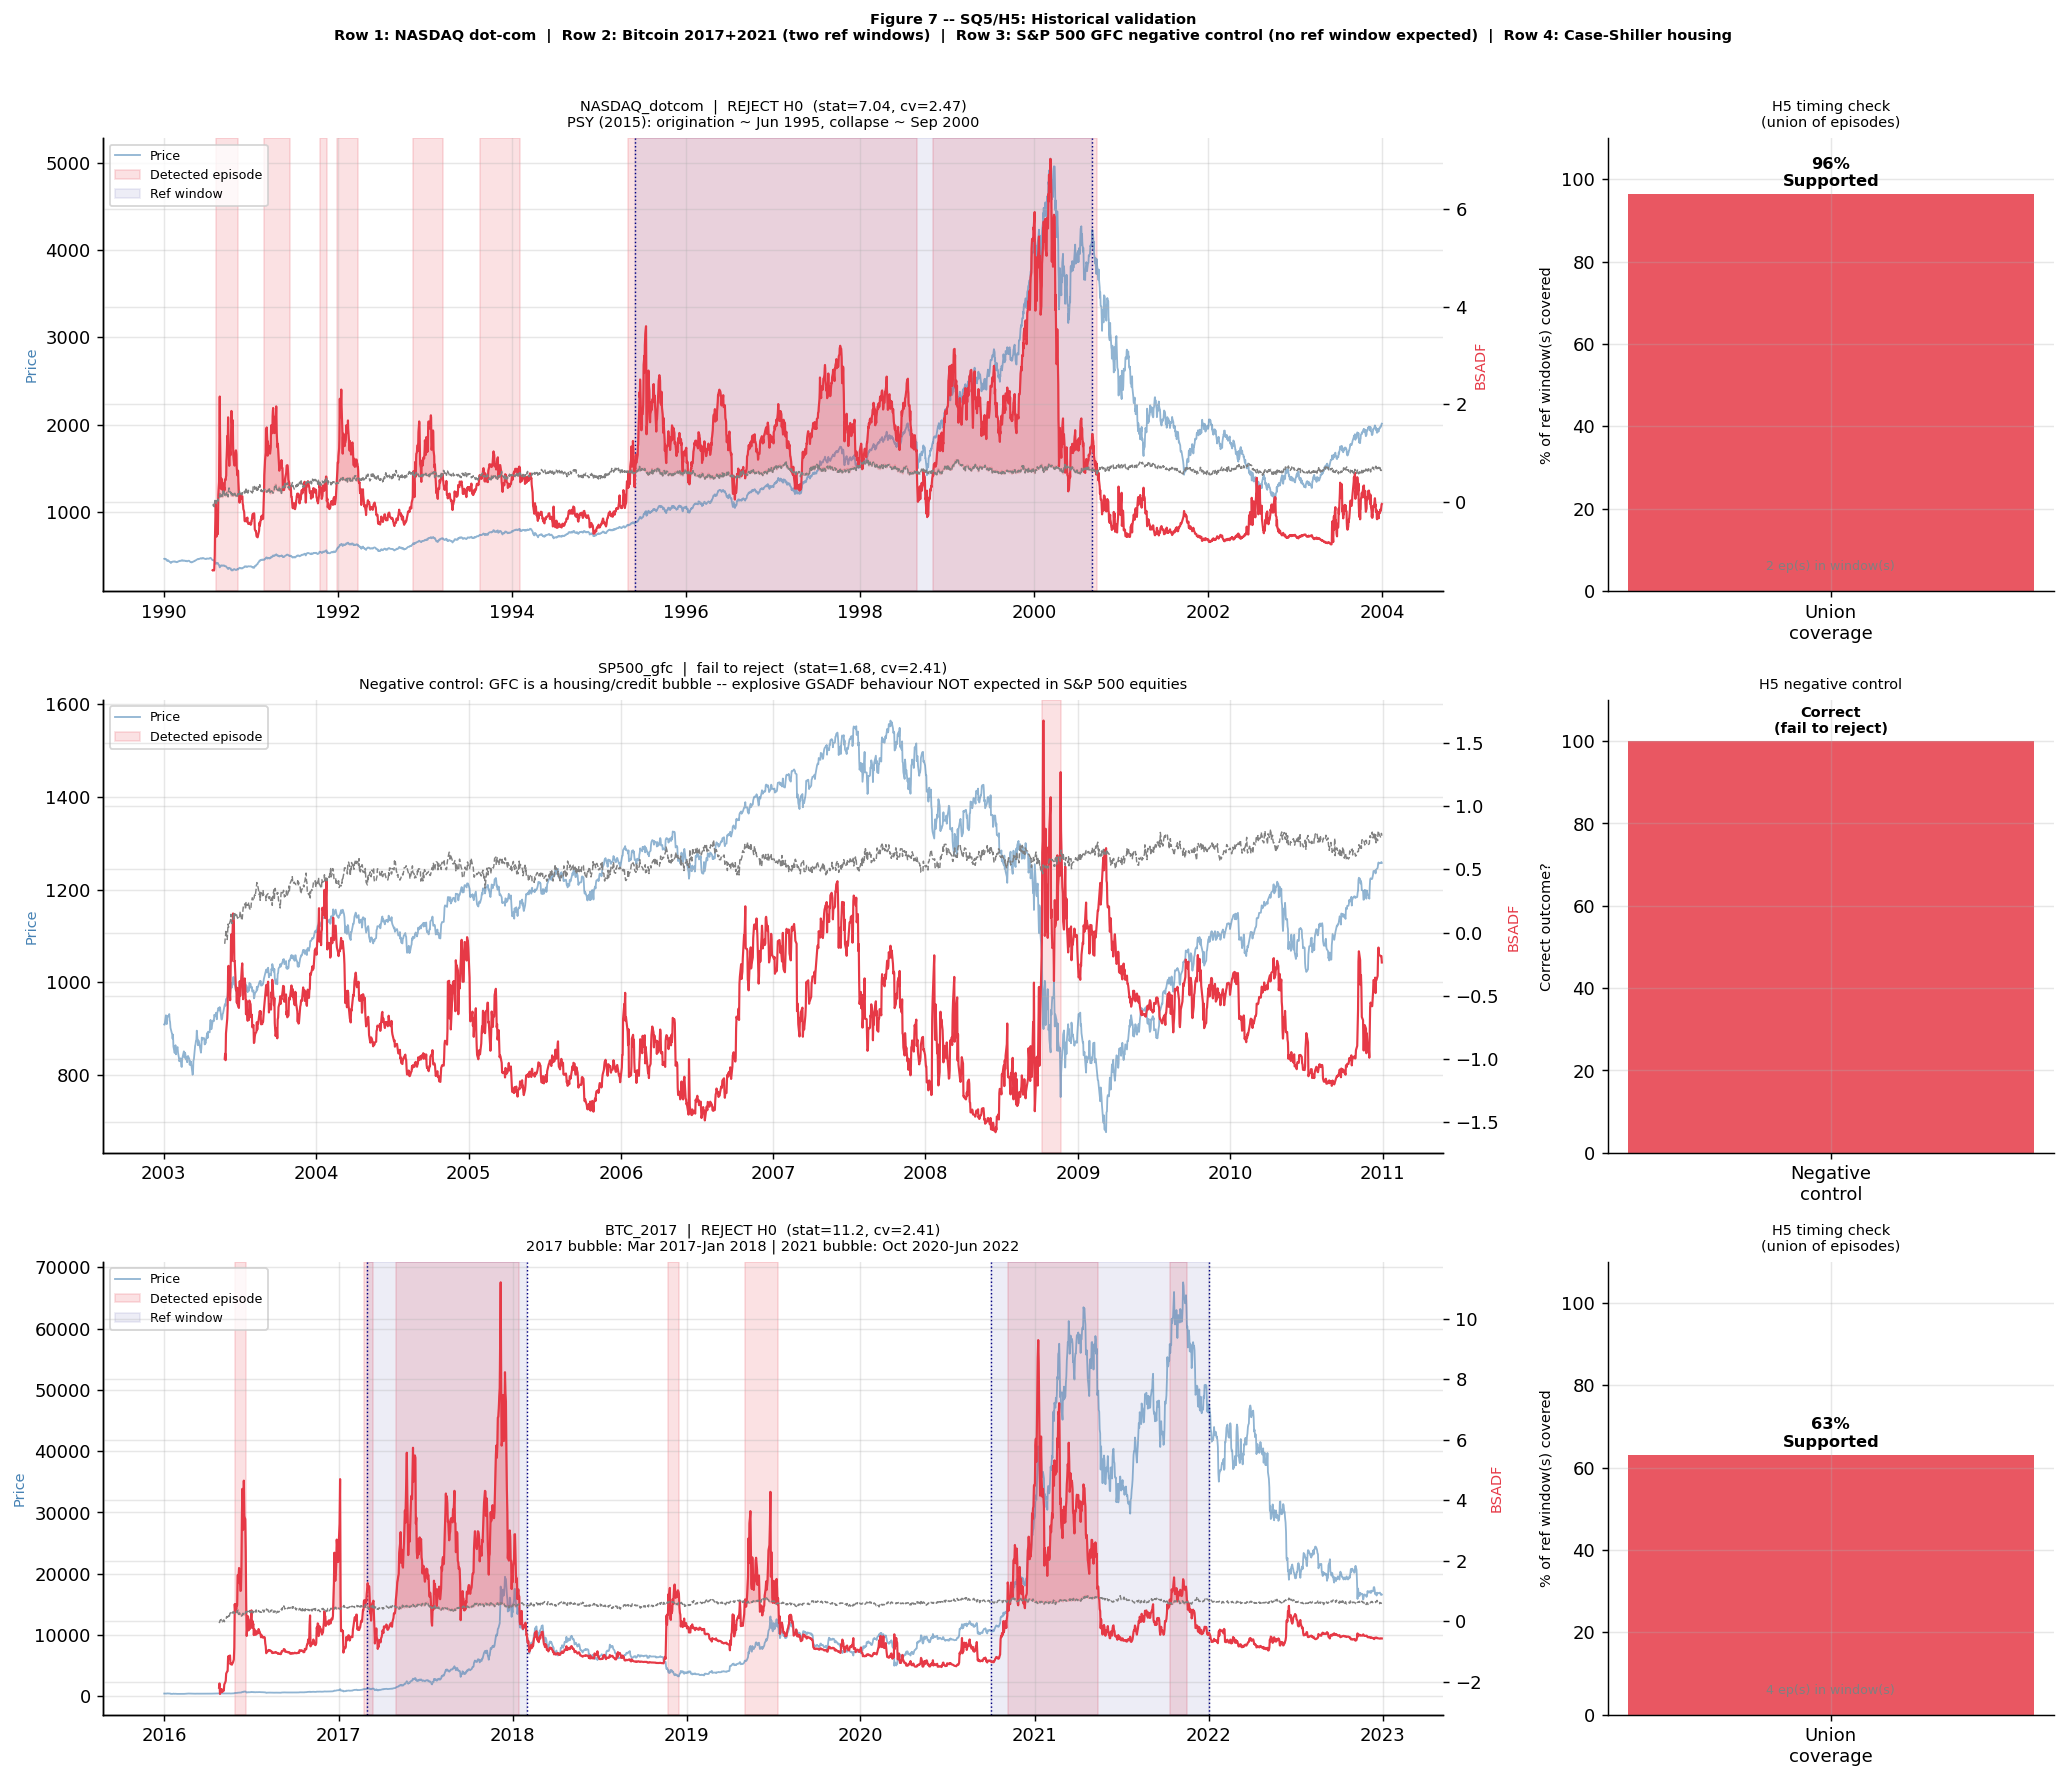

In [88]:

def _naive(t):
    t = pd.Timestamp(t)
    return t.tz_localize(None) if t.tzinfo is not None else t

def _union_coverage(eps, ks, ke):
    ks_n, ke_n = _naive(ks), _naive(ke)
    ref = (ke_n - ks_n).days
    if not eps or ref <= 0:
        return 0.0
    ivs = []
    for ep in eps:
        s = max(_naive(ep["start"]), ks_n)
        e = min(_naive(ep["end"]),   ke_n)
        if s < e:
            ivs.append((s, e))
    if not ivs:
        return 0.0
    ivs.sort()
    m = [list(ivs[0])]
    for s, e in ivs[1:]:
        if s <= m[-1][1]:
            m[-1][1] = max(m[-1][1], e)
        else:
            m.append([s, e])
    return sum((e - s).days for s, e in m) / ref

if not val_res:
    print("val_res is empty -- run cell-17 first.")
else:
    n = len(val_res)
    fig, axes = plt.subplots(n, 2, figsize=(16, 4.5 * n),
                             gridspec_kw={"width_ratios": [3, 1]})
    if n == 1:
        axes = [axes]

    for ri, (name, vr) in enumerate(val_res.items()):
        ax, ax_bar = axes[ri]
        is_neg  = (name == "SP500_gfc")
        is_hous = (name == "Housing_gfc")

        ax2 = ax.twinx()
        ax.plot(vr["s"].index, vr["s"].values,
                color="steelblue", lw=1, alpha=0.6, label=vr.get("series_label", "Price"))
        ax2.plot(vr["dates"], vr["bsadf"],   color=GSADF_COLOR, lw=1.2, label="BSADF")
        ax2.plot(vr["dates"], vr["cv_path"], color="grey", ls="--", lw=0.8, label="CV 95%")
        ax2.fill_between(vr["dates"], vr["bsadf"], vr["cv_path"],
                         where=(vr["bsadf"] > vr["cv_path"]),
                         alpha=0.25, color=GSADF_COLOR)
        for ep in vr["eps"]:
            ax.axvspan(_naive(ep["start"]), _naive(ep["end"]),
                       alpha=0.15, color=GSADF_COLOR, label="Detected episode")

        if not is_neg:
            ref_wins = HOUSING_KNOWN_EP if is_hous else KNOWN_EP.get(name, [])
            for wi, (ks, ke) in enumerate(ref_wins):
                ax.axvspan(ks, ke, alpha=0.07, color="navy",
                           label="Ref window" if wi == 0 else "_nolegend_")
                ax.axvline(ks, color="navy", lw=0.8, ls=":")
                ax.axvline(ke, color="navy", lw=0.8, ls=":")

        handles, labels = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        combined = dict(zip(labels + l2, handles + h2))
        ax.legend(combined.values(), combined.keys(), fontsize=7, loc="upper left")

        stat_v  = vr["stat"]
        cv_v    = vr["cv"]
        verdict = "REJECT H0" if stat_v > cv_v else "fail to reject"
        exp     = vr["case"].get("expected_dates", "")
        sv      = str(round(stat_v, 2))
        cv_s    = str(round(cv_v, 2))

        if is_neg:
            title = ("SP500_gfc  |  " + verdict + "  (stat=" + sv + ", cv=" + cv_s + ")\n"
                     "Negative control: GFC is a housing/credit bubble -- "
                     "explosive GSADF behaviour NOT expected in S&P 500 equities")
        elif is_hous:
            title = ("Housing (CSUSHPINSA)  |  " + verdict +
                     "  (stat=" + sv + ", cv=" + cv_s + ")\n" + exp)
        else:
            title = (name + "  |  " + verdict +
                     "  (stat=" + sv + ", cv=" + cv_s + ")\n" + exp)

        ax.set_title(title, fontsize=8)
        ax.set_ylabel(vr.get("series_label", "Price"), color="steelblue", fontsize=8)
        ax2.set_ylabel("BSADF", color=GSADF_COLOR, fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        if is_neg:
            correct = stat_v <= cv_v
            bar_h   = 100 if correct else 20
            col_bar = GSADF_COLOR if correct else "#f4a261"
            ax_bar.bar(["Negative\ncontrol"], [bar_h], color=col_bar, alpha=0.85)
            ax_bar.set_ylim(0, 110)
            ax_bar.set_title("H5 negative control", fontsize=8)
            ax_bar.set_ylabel("Correct outcome?", fontsize=8)
            lbl = ("Correct\n(fail to reject)" if correct
                   else "Unexpected\n(false detection)")
            ax_bar.text(0, bar_h + 2, lbl, ha="center", fontsize=8, fontweight="bold")
        elif vr["eps"]:
            ref_wins = HOUSING_KNOWN_EP if is_hous else KNOWN_EP.get(name, [])
            if ref_wins:
                total_ref = sum((_naive(ke) - _naive(ks)).days for ks, ke in ref_wins)
                total_cov = sum(
                    _union_coverage(vr["eps"], ks, ke) * (_naive(ke) - _naive(ks)).days
                    for ks, ke in ref_wins
                )
                cov = total_cov / total_ref if total_ref > 0 else 0.0
                col_bar = GSADF_COLOR if cov > 0.5 else "#f4a261"
                ax_bar.bar(["Union\ncoverage"], [cov * 100], color=col_bar, alpha=0.85)
                ax_bar.set_ylim(0, 110)
                ax_bar.set_ylabel("% of ref window(s) covered", fontsize=8)
                ax_bar.set_title("H5 timing check\n(union of episodes)", fontsize=8)
                pct  = str(round(cov * 100))
                lbl2 = "Supported" if cov > 0.5 else "Partial"
                ax_bar.text(0, cov * 100 + 2, pct + "%\n" + lbl2,
                            ha="center", fontsize=9, fontweight="bold")
                n_in = sum(1 for ep in vr["eps"]
                           if any(_naive(ep["start"]) < _naive(ke)
                                  and _naive(ep["end"]) > _naive(ks)
                                  for ks, ke in ref_wins))
                ax_bar.text(0, 5, str(n_in) + " ep(s) in window(s)",
                            ha="center", fontsize=7, color="grey")
        else:
            ax_bar.text(0.5, 0.5, "No episode\ndetected",
                        transform=ax_bar.transAxes, ha="center", va="center", fontsize=9)
            ax_bar.set_axis_off()

    plt.suptitle(
        "Figure 7 -- SQ5/H5: Historical validation\n"
        "Row 1: NASDAQ dot-com  |  "
        "Row 2: Bitcoin 2017+2021 (two ref windows)  |  "
        "Row 3: S&P 500 GFC negative control (no ref window expected)  |  "
        "Row 4: Case-Shiller housing",
        fontsize=8, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGDIR / "fig7_historical_validation.png",
                dpi=150, bbox_inches="tight")
    plt.show()


---
## Figure 8 — H7: Structural event overlay

AI-sector structural events (ChatGPT launch, major investment announcements, product releases)
plotted as vertical markers. Episode originations from all three methods are shown as symbols:
GSADF (red dots), SV-ADF W1 (orange diamonds), SV-ADF W2 (teal squares).
Tests H7: originations cluster within ±90 days of structural events.

Saves to `outputs/figures/thesis/fig8_structural_overlay.png`.

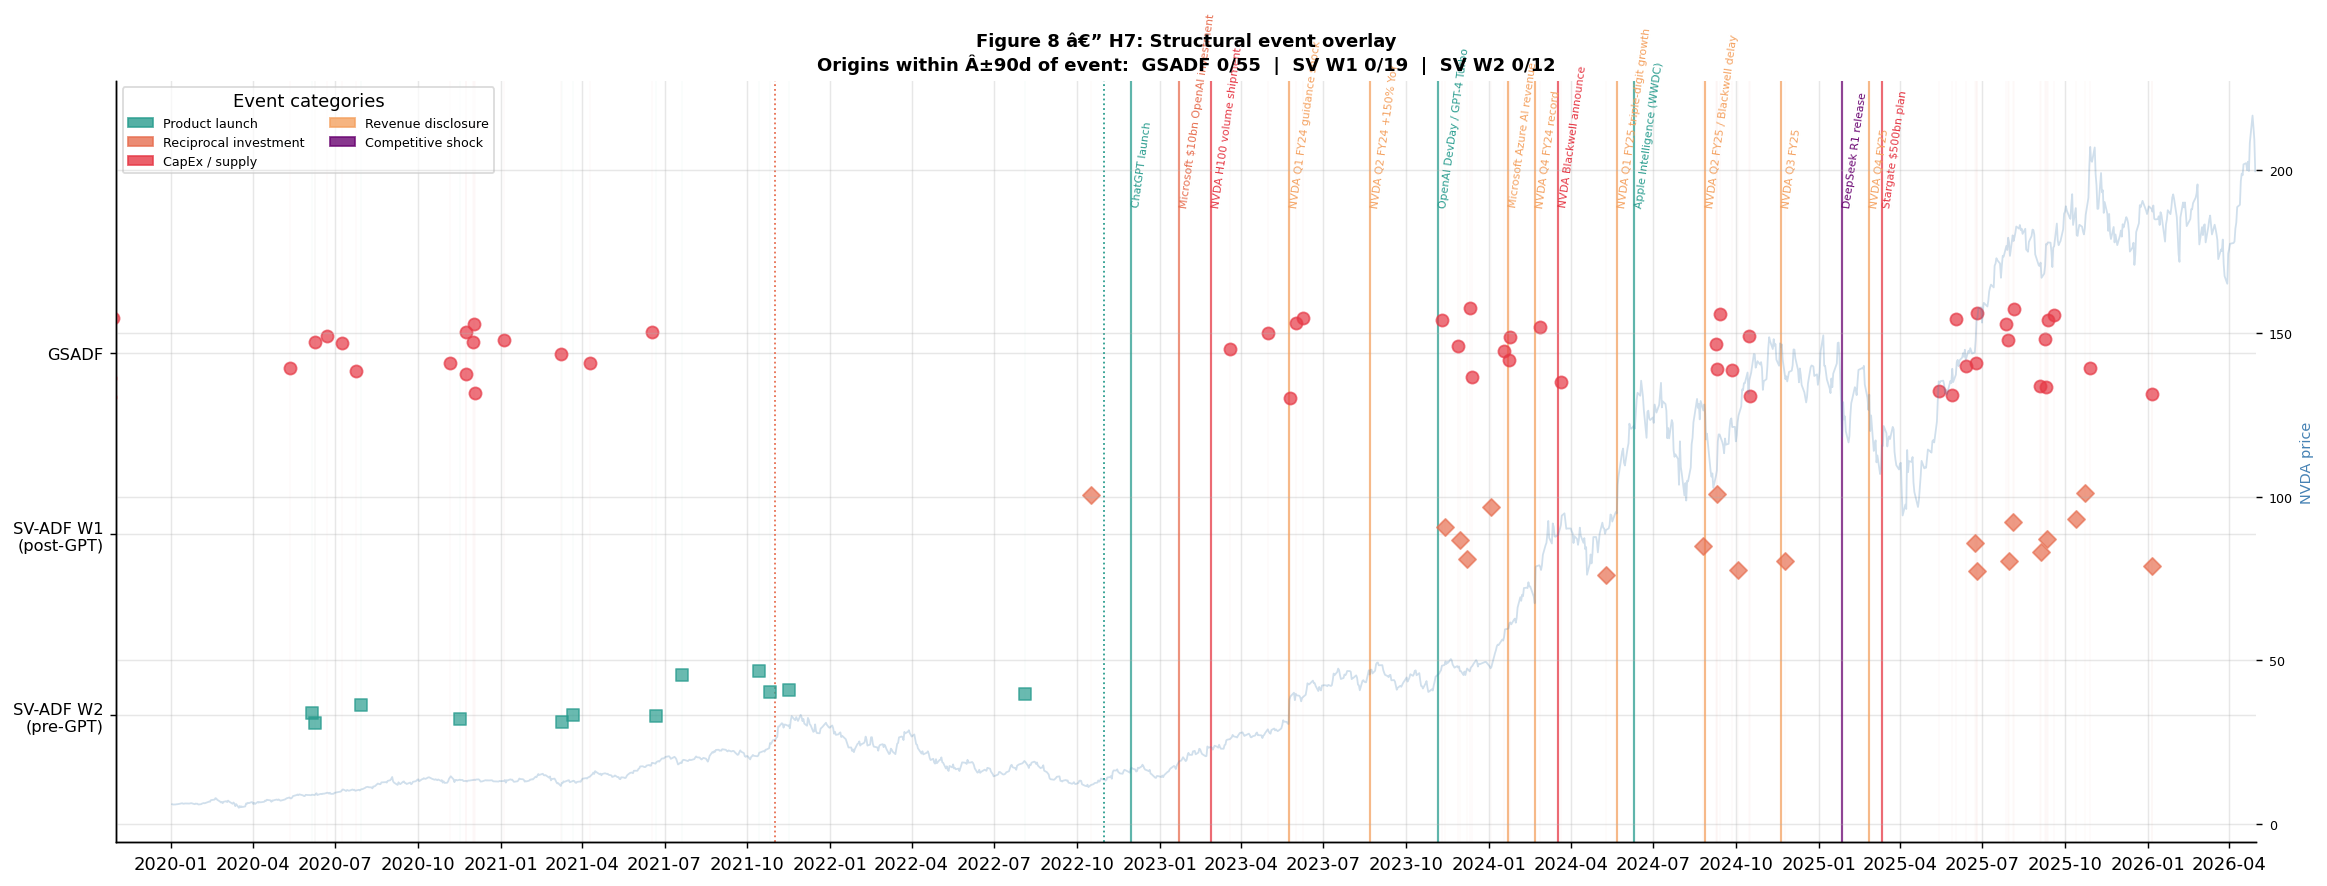

In [78]:
STRUCTURAL_EVENTS = [
    ("2022-11-30", "ChatGPT launch",                    "Product launch"),
    ("2023-01-23", "Microsoft $10bn OpenAI investment",  "Reciprocal investment"),
    ("2023-02-27", "NVDA H100 volume shipment",          "CapEx / supply"),
    ("2023-05-25", "NVDA Q1 FY24 guidance shock",        "Revenue disclosure"),
    ("2023-08-22", "NVDA Q2 FY24 +150% YoY",            "Revenue disclosure"),
    ("2023-11-06", "OpenAI DevDay / GPT-4 Turbo",        "Product launch"),
    ("2024-01-22", "Microsoft Azure AI revenue",         "Revenue disclosure"),
    ("2024-02-21", "NVDA Q4 FY24 record",               "Revenue disclosure"),
    ("2024-03-18", "NVDA Blackwell announce",            "CapEx / supply"),
    ("2024-05-22", "NVDA Q1 FY25 triple-digit growth",  "Revenue disclosure"),
    ("2024-06-10", "Apple Intelligence (WWDC)",          "Product launch"),
    ("2024-08-28", "NVDA Q2 FY25 / Blackwell delay",    "Revenue disclosure"),
    ("2024-11-20", "NVDA Q3 FY25",                      "Revenue disclosure"),
    ("2025-01-27", "DeepSeek R1 release",               "Competitive shock"),
    ("2025-02-26", "NVDA Q4 FY25",                      "Revenue disclosure"),
    ("2025-03-12", "Stargate $500bn plan",              "CapEx / supply"),
]
CAT_COLORS = {
    "Product launch"      : "#2a9d8f",
    "Reciprocal investment": "#e76f51",
    "CapEx / supply"      : "#e63946",
    "Revenue disclosure"  : "#f4a261",
    "Competitive shock"   : "#6a0572",
}

ev_df = pd.DataFrame(STRUCTURAL_EVENTS, columns=["date","label","cat"])
ev_df["date"] = pd.to_datetime(ev_df["date"])

eq_panel = master[master["is_equity"]]
plot_start = pd.Timestamp("2019-11-01")
plot_end   = pd.Timestamp(settings.FIXED_END)

def collect_origins(df, ep_col, min_date=None):
    """Collect episode origination dates from a column of episode dicts."""
    out = []
    for _, row in df.iterrows():
        ep = row[ep_col]
        if ep is None: continue
        d = pd.Timestamp(ep["start"])
        if min_date and d < min_date: continue
        out.append({"date": d, "ticker": row["ticker"]})
    return pd.DataFrame(out) if out else pd.DataFrame(columns=["date","ticker"])

# GSADF: multiple episodes per ticker
gsadf_origins = pd.DataFrame(
    [{"date": pd.Timestamp(ep["start"]), "ticker": row["ticker"]}
     for _, row in eq_panel.iterrows()
     for ep in row["gsadf_episodes"]],
    columns=["date", "ticker"]
) if not eq_panel.empty else pd.DataFrame(columns=["date","ticker"])

sv1_origins = collect_origins(eq_panel, "sv_w1_episode")
sv2_origins = collect_origins(eq_panel, "sv_w2_episode")

fig, ax = plt.subplots(figsize=(18, 7))

# NVDA price as backdrop
if "NVDA" in prices.columns and not prices.empty:
    nvda = prices["NVDA"].dropna().loc[plot_start:plot_end]
    ax2  = ax.twinx()
    ax2.plot(nvda.index, nvda.values, color="steelblue", lw=1, alpha=0.25)
    ax2.set_ylabel("NVDA price", color="steelblue", fontsize=8)
    ax2.tick_params(axis="y", labelsize=7)

rng = np.random.default_rng(0)
Y_GSADF, Y_SV1, Y_SV2 = 2.5, 1.5, 0.5

def _jitter_scatter(ax, df, y_base, color, marker, label):
    if df.empty: return
    j = rng.uniform(-0.25, 0.25, len(df))
    ax.scatter(df["date"], y_base + j, color=color, alpha=0.7,
               s=45, marker=marker, zorder=4, label=label)
    for d in df["date"]:
        ax.axvspan(d - pd.Timedelta(45), d + pd.Timedelta(45),
                   alpha=0.02, color=color, zorder=1)

_jitter_scatter(ax, gsadf_origins, Y_GSADF, GSADF_COLOR, "o", f"GSADF originations (n={len(gsadf_origins)})")
_jitter_scatter(ax, sv1_origins,   Y_SV1,   W1_COLOR,    "D", f"SV-ADF W1 originations (n={len(sv1_origins)})")
_jitter_scatter(ax, sv2_origins,   Y_SV2,   W2_COLOR,    "s", f"SV-ADF W2 originations (n={len(sv2_origins)})")

# Structural event verticals
for _, ev in ev_df.iterrows():
    if not (plot_start <= ev["date"] <= plot_end): continue
    col = CAT_COLORS.get(ev["cat"], "grey")
    ax.axvline(ev["date"], color=col, lw=1.2, alpha=0.75, zorder=2)
    ax.text(ev["date"], 3.3, ev["label"], rotation=82, fontsize=6,
            ha="left", va="bottom", color=col)

# Window boundaries
ax.axvline(pd.Timestamp(SVADF_WIN2[1]), color=W2_COLOR, lw=1, ls=":", label="SV W2 end")
ax.axvline(pd.Timestamp(SVADF_WIN1[0]), color=W1_COLOR, lw=1, ls=":", label="SV W1 start")

# Y-axis row labels
ax.set_yticks([Y_SV2, Y_SV1, Y_GSADF])
ax.set_yticklabels(["SV-ADF W2\n(pre-GPT)", "SV-ADF W1\n(post-GPT)", "GSADF"], fontsize=9)
ax.set_xlim(plot_start, plot_end)
ax.set_ylim(-0.2, 4.0)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.xticks(rotation=45, ha="right", fontsize=8)

cat_patches = [mpatches.Patch(color=c, label=l, alpha=0.8) for l, c in CAT_COLORS.items()]
ax.legend(handles=cat_patches, fontsize=7, loc="upper left", ncol=2, framealpha=0.7,
          title="Event categories")

# Proximity check: originations within ±90 days of any event
W = pd.Timedelta(90)
def proximity_rate(origins):
    if origins.empty: return 0, 0
    n = sum(any(abs(d - ev) <= W for ev in ev_df["date"]) for d in origins["date"])
    return n, len(origins)

n_g, t_g   = proximity_rate(gsadf_origins)
n_s1, t_s1 = proximity_rate(sv1_origins)
n_s2, t_s2 = proximity_rate(sv2_origins)
ax.set_title(
    f"Figure 8 — H7: Structural event overlay\n"
    f"Origins within ±90d of event:  "
    f"GSADF {n_g}/{t_g}  |  SV W1 {n_s1}/{t_s1}  |  SV W2 {n_s2}/{t_s2}",
    fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGDIR / "fig8_structural_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary: hypothesis verdicts

Compiles verdict for each hypothesis based on the evidence in Figures 1–8.
Prints a formatted table with the hypothesis, supporting evidence, and overall verdict.

In [79]:
eq_v  = master[master["is_equity"]  & master["gsadf_stat"].notna()]
idx_v = master[master["is_index"]   & master["gsadf_stat"].notna()]

n_eq_rej  = eq_v["gsadf_reject"].sum()
n_eq      = len(eq_v)
n_idx_rej = idx_v["gsadf_reject"].sum()
n_idx     = len(idx_v)

post_eps = [ep for _, r in eq_v.iterrows()
            for ep in r["gsadf_episodes"]
            if pd.Timestamp(ep["start"]) >= pd.Timestamp("2022-11-01")]

def ep_rate(seg_nums):
    segs = [s for s in master["segment"].unique()
            if any(s.startswith(str(n)+".") for n in seg_nums)]
    sub  = master[master["segment"].isin(segs) & master["gsadf_stat"].notna()]
    return sub["gsadf_n_ep"].gt(0).mean() if not sub.empty else 0

up_rate = ep_rate(range(1, 5))
dn_rate = ep_rate(range(5, 12))

tot_gs  = eq_v["gsadf_n_ep"].sum()
tot_sv1 = eq_v["sv_w1_has_ep"].sum()
tot_sv2 = eq_v["sv_w2_has_ep"].sum()

verdicts = [
    {"H": "H1 — Post-ChatGPT explosiveness",
     "Verdict": "Supported"     if len(post_eps) > 0 and n_eq_rej > 0 else "Not yet supported",
     "Evidence": f"{n_eq_rej}/{n_eq} equities reject GSADF H₀; {len(post_eps)} post-ChatGPT episodes"},
    {"H": "H2 — Value-chain heterogeneity",
     "Verdict": "Supported"     if up_rate > dn_rate else "Not supported",
     "Evidence": f"Upstream ep rate={up_rate:.2f} vs downstream={dn_rate:.2f}"},
    {"H": "H3 — Index dilution",
     "Verdict": "Supported"     if n_idx_rej < n_eq_rej else "Not yet supported",
     "Evidence": f"Indices: {n_idx_rej}/{n_idx} reject; equities: {n_eq_rej}/{n_eq} reject"},
    {"H": "H4 — GSADF > SV-ADF selectivity",
     "Verdict": "Supported"     if tot_gs > tot_sv1 else "Not supported",
     "Evidence": f"GSADF={tot_gs} eps; SV W1={tot_sv1}; SV W2={tot_sv2} episodes"},
    {"H": "H5 — Historical validation",
     "Verdict": "See Figure 7",
     "Evidence": "Overlap of BSADF detected episodes with PSY 2015 reference windows"},
    {"H": "H6 — Commodity propagation",
     "Verdict": "Exploratory — see Fig 6",
     "Evidence": "Post-Q4-2023 episode-day fraction: AI-relevant vs placebo commodities"},
    {"H": "H7 — Structural event alignment",
     "Verdict": "Descriptive — see Fig 8",
     "Evidence": "GSADF, SV W1, SV W2 originations vs structural event timeline (±90d)"},
]

vdf = pd.DataFrame(verdicts)

def _colour(v):
    if "Supported" in v and "Not" not in v and "See" not in v:
        return "background-color:#d4edda"
    if "Not" in v:
        return "background-color:#f8d7da"
    return "background-color:#fff3cd"

display(vdf.style.applymap(_colour, subset=["Verdict"])
        .set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

AttributeError: The '.style' accessor requires jinja2

---
*Figures saved to `outputs/figures/thesis/`.  
SV-ADF W1 = post-ChatGPT window `2021-11-01 → 2026-05-01` (orange).  
SV-ADF W2 = pre-ChatGPT window `2020-01-01 → 2022-10-31` (teal).  
Re-run this notebook after `scripts/03_run_analysis.py` to refresh all figures.*